<a href="https://colab.research.google.com/github/Alex-Roberts27/Research_Mock_DB62_EW46_RnaSeqPlots/blob/main/ISG_Genes_MockvEW46_Plots.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

We took HT-1080 fibrosarcoma cells and infected them with either DB62 (infects well and kills cells) or EW46 (infects a lot, but doesn't kill) at an MOI of 50 PFU for 48 h, and mock-infected them as a control for 72 h. We then removed the media and lysed/homogenized in 200 µl/well of Zymo DNA/RNA shield and stored it in your box at -20 °C. I took ~80 µl of each to take to UNC-CH, and we sent them for whole-cell RNA-sequencing to Plasmidsaurus. We want to see which genes are upregulated or downregulated during infection with DB62 compared to mock, but that are differentially expressed compared to EW46 (aka genes that are induced by DB62 specifically, not just any reovirus strain). Our samples are:


*   Samples 1 and 2: HT-1080_Mock 1, HT-1080_Mock 2 (two biological replicates,
mock-treated cells)
*   Samples 3 and 4: HT-1080_DB62 1, HT-1080_DB62 2 (two biological replicates, DB62-infected cells)
*   Samples 5 and 6: HT-1080_EW46 1, HT-1080_EW46 2 (two biological replicates, EW46-infected cells)

Code for Heatmaps came from:
1. https://github.com/mousepixels/sanbomics_scripts/blob/main/PyDeseq2_DE_tutorial.ipynb

Code for Volcano Plots came from:
1. https://www.youtube.com/watch?v=qHeIhEPKU98

This File explores ISG (Interferon Stimulated Genes and their expression in the samples)

# Load Packages and RNAseq File

In [1]:
%pip install pydeseq2
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
import pandas as pd

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 62.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.6/87.6 kB 4.5 MB/s eta 0:00:00


In [2]:
# Load the Excel file
# Use sheet_name=None to load all sheets, or specify one (e.g., sheet_name=0)
df = pd.read_excel('RNA-seq-matrix-for-efra.xlsx')

# Convert and save as CSV
# index=False prevents pandas from adding an extra column for row numbers
df.to_csv('RNA-seq-matrix-for-efra.csv', index=False)

In [3]:
counts = pd.read_csv('RNA-seq-matrix-for-efra.csv')
counts

,gene_id,gene_name,gene_biotype,HT-1080_Mock_1_cpm,HT-1080_Mock_1_count,HT-1080_Mock_2_cpm,HT-1080_Mock_2_count,HT-1080_DB62_1_cpm,HT-1080_DB62_1_count,HT-1080_DB62_2_cpm,HT-1080_DB62_2_count,HT-1080_EW46_1_cpm,HT-1080_EW46_1_count,HT-1080_EW46_2_cpm,HT-1080_EW46_2_count
0,ENSG00000000003,TSPAN6,protein_coding,18.845070,211.67,21.288051,259.33,16.962117,180.17,15.801986,161.17,20.766109,229.33,14.515106,171.25
1,ENSG00000000005,TNMD,protein_coding,0.000000,0.00,0.082089,1.00,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00
2,ENSG00000000419,DPM1,protein_coding,146.989231,1651.00,165.326550,2014.00,170.873301,1815.00,171.383456,1748.00,152.578787,1685.00,162.060629,1912.00
3,ENSG00000000457,SCYL3,protein_coding,6.766312,76.00,6.074560,74.00,6.307720,67.00,6.372955,65.00,5.342521,59.00,6.526500,77.00
4,ENSG00000000460,FIRRM,protein_coding,9.971408,112.00,11.738678,143.00,11.768134,125.00,10.196727,104.00,8.602365,95.00,12.459682,147.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78981,ERCC-00164,ERCC-00164,transgene,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00
78982,ERCC-00165,ERCC-00165,transgene,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00
78983,ERCC-00168,ERCC-00168,transgene,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00
78984,ERCC-00170,ERCC-00170,transgene,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00


In [4]:
#If the gene_biotype is not protein_coding, remove it from the sheet
counts = counts[counts.gene_biotype == 'protein_coding']
counts

,gene_id,gene_name,gene_biotype,HT-1080_Mock_1_cpm,HT-1080_Mock_1_count,HT-1080_Mock_2_cpm,HT-1080_Mock_2_count,HT-1080_DB62_1_cpm,HT-1080_DB62_1_count,HT-1080_DB62_2_cpm,HT-1080_DB62_2_count,HT-1080_EW46_1_cpm,HT-1080_EW46_1_count,HT-1080_EW46_2_cpm,HT-1080_EW46_2_count
0,ENSG00000000003,TSPAN6,protein_coding,18.845070,211.67,21.288051,259.33,16.962117,180.17,15.801986,161.17,20.766109,229.33,14.515106,171.25
1,ENSG00000000005,TNMD,protein_coding,0.000000,0.00,0.082089,1.00,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00
2,ENSG00000000419,DPM1,protein_coding,146.989231,1651.00,165.326550,2014.00,170.873301,1815.00,171.383456,1748.00,152.578787,1685.00,162.060629,1912.00
3,ENSG00000000457,SCYL3,protein_coding,6.766312,76.00,6.074560,74.00,6.307720,67.00,6.372955,65.00,5.342521,59.00,6.526500,77.00
4,ENSG00000000460,FIRRM,protein_coding,9.971408,112.00,11.738678,143.00,11.768134,125.00,10.196727,104.00,8.602365,95.00,12.459682,147.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78884,ENSG00000310558,NaN,protein_coding,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00
78886,ENSG00000310560,PAXX,protein_coding,25.373671,285.00,19.208745,234.00,19.488029,207.00,21.570000,220.00,22.275597,246.00,21.613734,255.00
78887,ENSG00000310561,NaN,protein_coding,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00
78888,ENSG00000310562,NaN,protein_coding,0.089030,1.00,0.246266,3.00,0.188290,2.00,0.000000,0.00,0.000000,0.00,0.169519,2.00


In [5]:
#Remove the gene_name column
counts = counts.drop(columns=['gene_name'])
#Remove the gene_biotype column
counts = counts.drop(columns=['gene_biotype'])
counts

,gene_id,HT-1080_Mock_1_cpm,HT-1080_Mock_1_count,HT-1080_Mock_2_cpm,HT-1080_Mock_2_count,HT-1080_DB62_1_cpm,HT-1080_DB62_1_count,HT-1080_DB62_2_cpm,HT-1080_DB62_2_count,HT-1080_EW46_1_cpm,HT-1080_EW46_1_count,HT-1080_EW46_2_cpm,HT-1080_EW46_2_count
0,ENSG00000000003,18.845070,211.67,21.288051,259.33,16.962117,180.17,15.801986,161.17,20.766109,229.33,14.515106,171.25
1,ENSG00000000005,0.000000,0.00,0.082089,1.00,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00
2,ENSG00000000419,146.989231,1651.00,165.326550,2014.00,170.873301,1815.00,171.383456,1748.00,152.578787,1685.00,162.060629,1912.00
3,ENSG00000000457,6.766312,76.00,6.074560,74.00,6.307720,67.00,6.372955,65.00,5.342521,59.00,6.526500,77.00
4,ENSG00000000460,9.971408,112.00,11.738678,143.00,11.768134,125.00,10.196727,104.00,8.602365,95.00,12.459682,147.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
78884,ENSG00000310558,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00
78886,ENSG00000310560,25.373671,285.00,19.208745,234.00,19.488029,207.00,21.570000,220.00,22.275597,246.00,21.613734,255.00
78887,ENSG00000310561,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00
78888,ENSG00000310562,0.089030,1.00,0.246266,3.00,0.188290,2.00,0.000000,0.00,0.000000,0.00,0.169519,2.00


In [6]:
#Makes final counts dataframe with raw gene counts by samples.
columns_to_drop = [
    'HT-1080_Mock_1_cpm',
    'HT-1080_Mock_2_cpm',
    'HT-1080_DB62_1_cpm',
    'HT-1080_DB62_2_cpm',
    'HT-1080_EW46_1_cpm',
    'HT-1080_EW46_2_cpm'
]
counts = counts.drop(columns=columns_to_drop)
counts

,gene_id,HT-1080_Mock_1_count,HT-1080_Mock_2_count,HT-1080_DB62_1_count,HT-1080_DB62_2_count,HT-1080_EW46_1_count,HT-1080_EW46_2_count
0,ENSG00000000003,211.67,259.33,180.17,161.17,229.33,171.25
1,ENSG00000000005,0.00,1.00,0.00,0.00,0.00,0.00
2,ENSG00000000419,1651.00,2014.00,1815.00,1748.00,1685.00,1912.00
3,ENSG00000000457,76.00,74.00,67.00,65.00,59.00,77.00
4,ENSG00000000460,112.00,143.00,125.00,104.00,95.00,147.00
...,...,...,...,...,...,...,...
78884,ENSG00000310558,0.00,0.00,0.00,0.00,0.00,0.00
78886,ENSG00000310560,285.00,234.00,207.00,220.00,246.00,255.00
78887,ENSG00000310561,0.00,0.00,0.00,0.00,0.00,0.00
78888,ENSG00000310562,1.00,3.00,2.00,0.00,0.00,2.00


In [7]:
counts = counts.set_index('gene_id')
counts

,HT-1080_Mock_1_count,HT-1080_Mock_2_count,HT-1080_DB62_1_count,HT-1080_DB62_2_count,HT-1080_EW46_1_count,HT-1080_EW46_2_count
gene_id,,,,,,
ENSG00000000003,211.67,259.33,180.17,161.17,229.33,171.25
ENSG00000000005,0.00,1.00,0.00,0.00,0.00,0.00
ENSG00000000419,1651.00,2014.00,1815.00,1748.00,1685.00,1912.00
ENSG00000000457,76.00,74.00,67.00,65.00,59.00,77.00
ENSG00000000460,112.00,143.00,125.00,104.00,95.00,147.00
...,...,...,...,...,...,...
ENSG00000310558,0.00,0.00,0.00,0.00,0.00,0.00
ENSG00000310560,285.00,234.00,207.00,220.00,246.00,255.00
ENSG00000310561,0.00,0.00,0.00,0.00,0.00,0.00


# Filter and clean Counts Dataframe along with deseq analysis on whole dataframe

In [8]:
#Selects for only numeric rows, removes rows where NA is present since they can't be used in ddseq
numeric_columns = counts.select_dtypes(include=['number']).columns
counts = counts[counts[numeric_columns].sum(axis=1) > 0]
counts

,HT-1080_Mock_1_count,HT-1080_Mock_2_count,HT-1080_DB62_1_count,HT-1080_DB62_2_count,HT-1080_EW46_1_count,HT-1080_EW46_2_count
gene_id,,,,,,
ENSG00000000003,211.67,259.33,180.17,161.17,229.33,171.25
ENSG00000000005,0.00,1.00,0.00,0.00,0.00,0.00
ENSG00000000419,1651.00,2014.00,1815.00,1748.00,1685.00,1912.00
ENSG00000000457,76.00,74.00,67.00,65.00,59.00,77.00
ENSG00000000460,112.00,143.00,125.00,104.00,95.00,147.00
...,...,...,...,...,...,...
ENSG00000310517,2207.50,2461.50,2048.00,2170.00,2375.50,2465.00
ENSG00000310525,24.50,34.50,26.50,26.50,22.50,21.00
ENSG00000310560,285.00,234.00,207.00,220.00,246.00,255.00


In [9]:
#Can change counts filter. Currently at 5, but can be from 1 to 10 in an acceptable way.
  #Selects for genes where a raw count is observed and a significant enough change is observed between samples
sig_counts = counts[~(counts < 5).all(axis=1)]
sig_counts

,HT-1080_Mock_1_count,HT-1080_Mock_2_count,HT-1080_DB62_1_count,HT-1080_DB62_2_count,HT-1080_EW46_1_count,HT-1080_EW46_2_count
gene_id,,,,,,
ENSG00000000003,211.67,259.33,180.17,161.17,229.33,171.25
ENSG00000000419,1651.00,2014.00,1815.00,1748.00,1685.00,1912.00
ENSG00000000457,76.00,74.00,67.00,65.00,59.00,77.00
ENSG00000000460,112.00,143.00,125.00,104.00,95.00,147.00
ENSG00000000971,5.00,4.00,4.50,4.00,6.00,5.50
...,...,...,...,...,...,...
ENSG00000300510,76.17,59.00,60.58,36.33,47.17,39.00
ENSG00000310517,2207.50,2461.50,2048.00,2170.00,2375.50,2465.00
ENSG00000310525,24.50,34.50,26.50,26.50,22.50,21.00


In [10]:
#Checks to see if any NA raw count colums exist
sig_counts.isnull().sum()

,0
HT-1080_Mock_1_count,0
HT-1080_Mock_2_count,0
HT-1080_DB62_1_count,0
HT-1080_DB62_2_count,0
HT-1080_EW46_1_count,0
HT-1080_EW46_2_count,0


In [11]:
flippedcounts = sig_counts.T
flippedcounts

gene_id,ENSG00000000003,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000971,ENSG00000001036,ENSG00000001084,ENSG00000001167,ENSG00000001460,ENSG00000001461,...,ENSG00000293565,ENSG00000293600,ENSG00000293606,ENSG00000293615,ENSG00000293642,ENSG00000300510,ENSG00000310517,ENSG00000310525,ENSG00000310560,ENSG00000310576
HT-1080_Mock_1_count,211.67,1651.0,76.0,112.0,5.0,658.0,156.0,146.33,146.0,290.0,...,4.0,133.0,740.00,8.17,82.00,76.17,2207.5,24.5,285.0,255.5
HT-1080_Mock_2_count,259.33,2014.0,74.0,143.0,4.0,772.0,151.0,142.67,143.0,328.0,...,2.0,125.5,803.92,8.83,87.00,59.00,2461.5,34.5,234.0,234.0
HT-1080_DB62_1_count,180.17,1815.0,67.0,125.0,4.5,604.0,136.0,134.33,131.0,254.0,...,6.0,107.5,591.58,4.33,78.50,60.58,2048.0,26.5,207.0,230.5
HT-1080_DB62_2_count,161.17,1748.0,65.0,104.0,4.0,562.0,140.0,115.00,132.5,251.0,...,5.0,103.0,574.08,10.00,87.25,36.33,2170.0,26.5,220.0,198.0
HT-1080_EW46_1_count,229.33,1685.0,59.0,95.0,6.0,564.0,161.0,107.33,140.0,272.0,...,5.5,133.0,597.42,8.17,101.50,47.17,2375.5,22.5,246.0,223.5
HT-1080_EW46_2_count,171.25,1912.0,77.0,147.0,5.5,664.0,162.0,161.00,141.5,317.0,...,4.0,152.0,620.67,5.33,107.00,39.00,2465.0,21.0,255.0,225.0


In [12]:
#Index part is relevant to the samples the counts dataframe has, they are changeable
metadata = pd.DataFrame(zip(flippedcounts.index, ['Mock','Mock','DB62','DB62', 'EW46', 'EW46']),
                        columns = ['Sample', 'Condition'])

In [13]:
metadata = metadata.set_index('Sample')
metadata

,Condition
Sample,
HT-1080_Mock_1_count,Mock
HT-1080_Mock_2_count,Mock
HT-1080_DB62_1_count,DB62
HT-1080_DB62_2_count,DB62
HT-1080_EW46_1_count,EW46
HT-1080_EW46_2_count,EW46


In [14]:
flippedcounts = flippedcounts.round().astype(int)
dds = DeseqDataSet(counts=flippedcounts,
            metadata=metadata,
            design="~Condition")

In [15]:
dds.deseq2()

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.02 seconds.

Fitting dispersions...
... done in 14.45 seconds.

Fitting dispersion trend curve...
... done in 0.41 seconds.

/usr/local/lib/python3.12/dist-packages/pydeseq2/dds.py:548: UserWarning: As the residual degrees of freedom is less than 3, the distribution of log dispersions is especially asymmetric and likely to be poorly estimated by the MAD.
  self.fit_dispersion_prior()
Fitting MAP dispersions...
... done in 19.31 seconds.

Fitting LFCs...
... done in 9.07 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.



In [16]:
dds

AnnData object with n_obs × n_vars = 6 × 13883
    obs: 'Condition', 'size_factors', 'replaceable'
    var: '_normed_means', 'non_zero', '_MoM_dispersions', 'genewise_dispersions', '_genewise_converged', 'fitted_dispersions', 'MAP_dispersions', '_MAP_converged', 'dispersions', '_outlier_genes', '_LFC_converged', 'replaced', 'refitted', '_pvalue_cooks_outlier'
    uns: 'trend_coeffs', 'disp_function_type', '_squared_logres', 'prior_disp_var'
    obsm: 'design_matrix', '_mu_LFC', '_hat_diagonals'
    varm: 'LFC'
    layers: 'normed_counts', '_mu_hat', 'cooks'

# Making non-filtered gene dataframe for plots

In [17]:
# Example: Comparing EW46 vs Mock
stat_res = DeseqStats(dds, n_cpus=8, contrast = ('Condition','EW46','Mock'))

#Uses DB62 as the control, so when using them vs mock do (DB62, mock) and (EW46, mock)

In [18]:
stat_res.summary()

Running Wald tests...


Log2 fold change & Wald test p-value: Condition EW46 vs Mock
                    baseMean  log2FoldChange     lfcSE      stat    pvalue  \
gene_id                                                                      
ENSG00000000003   200.359456       -0.218503  0.185998 -1.174762  0.240090   
ENSG00000000419  1797.981961       -0.018558  0.080007 -0.231956  0.816572   
ENSG00000000457    69.313933       -0.139279  0.273783 -0.508721  0.610948   
ENSG00000000460   120.029404       -0.072659  0.227266 -0.319709  0.749189   
ENSG00000000971     4.795372        0.419366  0.998471  0.420008  0.674480   
...                      ...             ...       ...       ...       ...   
ENSG00000300510    52.821895       -0.644470  0.339907 -1.896020  0.057957   
ENSG00000310517  2275.847809        0.060732  0.071767  0.846233  0.397423   
ENSG00000310525    25.449664       -0.418367  0.451463 -0.926691  0.354087   
ENSG00000310560   239.852841       -0.047735  0.163079 -0.292713  0.769742   
ENS

... done in 21.10 seconds.



In [19]:
res = stat_res.results_df

In [20]:
res

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene_id,,,,,,
ENSG00000000003,200.359456,-0.218503,0.185998,-1.174762,0.240090,0.609717
ENSG00000000419,1797.981961,-0.018558,0.080007,-0.231956,0.816572,0.954281
ENSG00000000457,69.313933,-0.139279,0.273783,-0.508721,0.610948,0.877224
ENSG00000000460,120.029404,-0.072659,0.227266,-0.319709,0.749189,0.934995
ENSG00000000971,4.795372,0.419366,0.998471,0.420008,0.674480,NaN
...,...,...,...,...,...,...
ENSG00000300510,52.821895,-0.644470,0.339907,-1.896020,0.057957,0.289955
ENSG00000310517,2275.847809,0.060732,0.071767,0.846233,0.397423,0.757962
ENSG00000310525,25.449664,-0.418367,0.451463,-0.926691,0.354087,NaN


In [21]:
#Drops rows where deseq determined gene wasn't relevant, i.e. NA
res = res.dropna(how='any')
res

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene_id,,,,,,
ENSG00000000003,200.359456,-0.218503,0.185998,-1.174762,0.240090,0.609717
ENSG00000000419,1797.981961,-0.018558,0.080007,-0.231956,0.816572,0.954281
ENSG00000000457,69.313933,-0.139279,0.273783,-0.508721,0.610948,0.877224
ENSG00000000460,120.029404,-0.072659,0.227266,-0.319709,0.749189,0.934995
ENSG00000001036,632.717549,-0.212870,0.105085,-2.025705,0.042795,0.240455
...,...,...,...,...,...,...
ENSG00000293642,90.006706,0.313871,0.239545,1.310283,0.190100,0.545605
ENSG00000300510,52.821895,-0.644470,0.339907,-1.896020,0.057957,0.289955
ENSG00000310517,2275.847809,0.060732,0.071767,0.846233,0.397423,0.757962


In [22]:
!pip install sanbomics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 16.3 MB/s eta 0:00:00


In [23]:
from sanbomics.tools import id_map

In [24]:
mapper = id_map(species = "human")
mapper.mapper

{'ENSG00000210049': 'MT-TF',
 'ENSG00000211459': 'MT-RNR1',
 'ENSG00000210077': 'MT-TV',
 'ENSG00000210082': 'MT-RNR2',
 'ENSG00000209082': 'MT-TL1',
 'ENSG00000198888': 'MT-ND1',
 'ENSG00000210100': 'MT-TI',
 'ENSG00000210107': 'MT-TQ',
 'ENSG00000210112': 'MT-TM',
 'ENSG00000198763': 'MT-ND2',
 'ENSG00000210117': 'MT-TW',
 'ENSG00000210127': 'MT-TA',
 'ENSG00000210135': 'MT-TN',
 'ENSG00000210140': 'MT-TC',
 'ENSG00000210144': 'MT-TY',
 'ENSG00000198804': 'MT-CO1',
 'ENSG00000210151': 'MT-TS1',
 'ENSG00000210154': 'MT-TD',
 'ENSG00000198712': 'MT-CO2',
 'ENSG00000210156': 'MT-TK',
 'ENSG00000228253': 'MT-ATP8',
 'ENSG00000198899': 'MT-ATP6',
 'ENSG00000198938': 'MT-CO3',
 'ENSG00000210164': 'MT-TG',
 'ENSG00000198840': 'MT-ND3',
 'ENSG00000210174': 'MT-TR',
 'ENSG00000212907': 'MT-ND4L',
 'ENSG00000198886': 'MT-ND4',
 'ENSG00000210176': 'MT-TH',
 'ENSG00000210184': 'MT-TS2',
 'ENSG00000210191': 'MT-TL2',
 'ENSG00000198786': 'MT-ND5',
 'ENSG00000198695': 'MT-ND6',
 'ENSG00000210194': 

In [25]:
res["Symbol"] = res.index.map(mapper.mapper)

/tmp/ipykernel_28964/1000349856.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  res["Symbol"] = res.index.map(mapper.mapper)


In [26]:
res

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Symbol
gene_id,,,,,,,
ENSG00000000003,200.359456,-0.218503,0.185998,-1.174762,0.240090,0.609717,TSPAN6
ENSG00000000419,1797.981961,-0.018558,0.080007,-0.231956,0.816572,0.954281,DPM1
ENSG00000000457,69.313933,-0.139279,0.273783,-0.508721,0.610948,0.877224,SCYL3
ENSG00000000460,120.029404,-0.072659,0.227266,-0.319709,0.749189,0.934995,C1orf112
ENSG00000001036,632.717549,-0.212870,0.105085,-2.025705,0.042795,0.240455,FUCA2
...,...,...,...,...,...,...,...
ENSG00000293642,90.006706,0.313871,0.239545,1.310283,0.190100,0.545605,NaN
ENSG00000300510,52.821895,-0.644470,0.339907,-1.896020,0.057957,0.289955,NaN
ENSG00000310517,2275.847809,0.060732,0.071767,0.846233,0.397423,0.757962,NaN


In [27]:
#res dataframe to a csv file
#res.to_csv('fullgenesetDB62vEW46.csv')
#only for a volcano plot if we need to make a full one without having preselected genes

# Finding ISG Genes in Res Dataframe and filtering for them only

In [28]:
# Load the Excel file
# Use sheet_name=None to load all sheets, or specify one (e.g., sheet_name=0)
df = pd.read_excel('ISG_Table.xlsx')

# Convert and save as CSV
# index=False prevents pandas from adding an extra column for row numbers
df.to_csv('ISG_Table.csv', index=False)

In [29]:
isgset = pd.read_csv('ISG_Table.csv')
isgset

,Genes
0,ABTB2
1,AC025171.1
2,ADAM9
3,ADAR
4,AIDA
...,...
418,ZBP1
419,ZC3HAV1
420,ZCCHC2
421,ZFP36L2


In [30]:
#Extract list of Genes from isgset as a string
isglist = isgset['Genes'].tolist()
isglist

['ABTB2',
 'AC025171.1',
 'ADAM9',
 'ADAR',
 'AIDA',
 'AKR7A2',
 'ANKFY1',
 'AP3M2',
 'APOBEC3G',
 'APOL1',
 'APOL2',
 'APOL3',
 'APOL4',
 'APOL6',
 'ARAP2',
 'ARID3A',
 'ARID5B',
 'ARL4A',
 'ATP10A',
 'ATP6V0A4',
 'ATP6V0B',
 'AUTS2',
 'AVPR2',
 'B2M',
 'BAG1',
 'BAK1',
 'BANK1',
 'BATF2',
 'BAX',
 'BBC3',
 'BBX',
 'BCL2',
 'BCLAF1',
 'BPGM',
 'BRCA1',
 'BST2',
 'BTG1',
 'C1R',
 'C1S',
 'CALD1',
 'CALR',
 'CASP1',
 'CASP3',
 'CASP4',
 'CASP7',
 'CASP8',
 'CCDC91',
 'CCL2',
 'CCL5',
 'CCL7',
 'CCNYL1',
 'CCRL2',
 'CD164',
 'CD274',
 'CD38',
 'CD40',
 'CD47',
 'CD69',
 'CD74',
 'CD80',
 'CD86',
 'CDK1',
 'CDKN1A',
 'CDKN1B',
 'CEACAM1',
 'CEBPD',
 'CFB',
 'CFH',
 'CGAS',
 'CIITA',
 'CLIC4',
 'CMKLR1',
 'CMPK2',
 'CMTR1',
 'CNP',
 'COL16A1',
 'CSF1',
 'CSF2RB',
 'CSRP3',
 'CTR9',
 'CX3CL1',
 'CXCL10',
 'CXCL11',
 'CXCL9',
 'CYB561D2',
 'CYCS',
 'CYP24A1',
 'DCK',
 'DDIT4',
 'DDX1',
 'DDX17',
 'DDX21',
 'DDX58',
 'DDX60',
 'DHX58',
 'DNAJC2',
 'DTX3L',
 'E2F2',
 'EHD4',
 'EIF2AK2',
 'EIF2

In [31]:
#Search res dataframe for genes in isglist and build dataframe with only those genes
isg_res = res[res['Symbol'].isin(isglist)]
isg_res

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Symbol
gene_id,,,,,,,
ENSG00000002549,846.097218,0.582537,0.090251,6.454638,1.084777e-10,9.880983e-09,LAP3
ENSG00000006062,103.732503,-0.016245,0.221542,-0.073326,9.415464e-01,9.875520e-01,MAP3K14
ENSG00000011422,2682.585392,-0.170885,0.068786,-2.484303,1.298053e-02,1.070610e-01,PLAUR
ENSG00000011485,561.104777,-0.096096,0.105417,-0.911579,3.619906e-01,7.311285e-01,PPP5C
ENSG00000012048,96.441923,0.570461,0.236082,2.416370,1.567612e-02,1.227608e-01,BRCA1
...,...,...,...,...,...,...,...
ENSG00000239713,284.602158,0.046119,0.144183,0.319866,7.490700e-01,9.349946e-01,APOBEC3G
ENSG00000240065,724.928708,0.162846,0.099230,1.641093,1.007781e-01,3.890260e-01,PSMB9
ENSG00000243279,397.427089,-0.042906,0.125672,-0.341411,7.327941e-01,9.297927e-01,PRAF2


# Filtering down gene dataframe to only significant genes, can't use it for volcano plot

In [32]:
sigs = isg_res[(isg_res.padj < 0.05) & (abs(isg_res.log2FoldChange) > 1)]
#Selects for only significantly different genes by adjp-value and log2fold change.
#See https://pmc.ncbi.nlm.nih.gov/articles/PMC4670015/ for what values to select at.

In [33]:
sigs

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Symbol
gene_id,,,,,,,
ENSG00000055332,1025.625072,1.613955,0.089190,18.095629,3.449851e-73,3.582325e-70,EIF2AK2
ENSG00000059378,95.287971,1.008233,0.237317,4.248468,2.152377e-05,6.459618e-04,PARP12
ENSG00000068079,355.159654,1.332627,0.133572,9.976823,1.925332e-23,4.543783e-21,IFI35
ENSG00000073756,82.628921,2.766809,0.284695,9.718512,2.514277e-22,5.554948e-20,PTGS2
ENSG00000089127,362.226324,2.892141,0.163580,17.680246,5.953620e-70,4.755568e-67,OAS1
ENSG00000101347,204.141243,1.698723,0.174640,9.727016,2.312779e-22,5.220848e-20,SAMHD1
ENSG00000106785,253.797049,1.065932,0.159124,6.698736,2.102302e-11,2.040215e-09,TRIM14
ENSG00000107201,248.673660,1.697653,0.163487,10.384006,2.932087e-25,7.611699e-23,DDX58
ENSG00000108771,83.800188,1.526254,0.285154,5.352385,8.680249e-08,5.035514e-06,DHX58


In [34]:
#Remove rows where symbol is NaN
cleanedsigs = sigs.dropna(subset=['Symbol'])
cleanedsigs #Final dataframe for heatmaps

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Symbol
gene_id,,,,,,,
ENSG00000055332,1025.625072,1.613955,0.089190,18.095629,3.449851e-73,3.582325e-70,EIF2AK2
ENSG00000059378,95.287971,1.008233,0.237317,4.248468,2.152377e-05,6.459618e-04,PARP12
ENSG00000068079,355.159654,1.332627,0.133572,9.976823,1.925332e-23,4.543783e-21,IFI35
ENSG00000073756,82.628921,2.766809,0.284695,9.718512,2.514277e-22,5.554948e-20,PTGS2
ENSG00000089127,362.226324,2.892141,0.163580,17.680246,5.953620e-70,4.755568e-67,OAS1
ENSG00000101347,204.141243,1.698723,0.174640,9.727016,2.312779e-22,5.220848e-20,SAMHD1
ENSG00000106785,253.797049,1.065932,0.159124,6.698736,2.102302e-11,2.040215e-09,TRIM14
ENSG00000107201,248.673660,1.697653,0.163487,10.384006,2.932087e-25,7.611699e-23,DDX58
ENSG00000108771,83.800188,1.526254,0.285154,5.352385,8.680249e-08,5.035514e-06,DHX58


In [35]:
cleanedsigs.info()

<class 'pandas.core.frame.DataFrame'>
Index: 43 entries, ENSG00000055332 to ENSG00000213928
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   baseMean        43 non-null     float64
 1   log2FoldChange  43 non-null     float64
 2   lfcSE           43 non-null     float64
 3   stat            43 non-null     float64
 4   pvalue          43 non-null     float64
 5   padj            43 non-null     float64
 6   Symbol          43 non-null     object 
dtypes: float64(6), object(1)
memory usage: 2.7+ KB


# Volcano with all genes

In [36]:
isg_res

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Symbol
gene_id,,,,,,,
ENSG00000002549,846.097218,0.582537,0.090251,6.454638,1.084777e-10,9.880983e-09,LAP3
ENSG00000006062,103.732503,-0.016245,0.221542,-0.073326,9.415464e-01,9.875520e-01,MAP3K14
ENSG00000011422,2682.585392,-0.170885,0.068786,-2.484303,1.298053e-02,1.070610e-01,PLAUR
ENSG00000011485,561.104777,-0.096096,0.105417,-0.911579,3.619906e-01,7.311285e-01,PPP5C
ENSG00000012048,96.441923,0.570461,0.236082,2.416370,1.567612e-02,1.227608e-01,BRCA1
...,...,...,...,...,...,...,...
ENSG00000239713,284.602158,0.046119,0.144183,0.319866,7.490700e-01,9.349946e-01,APOBEC3G
ENSG00000240065,724.928708,0.162846,0.099230,1.641093,1.007781e-01,3.890260e-01,PSMB9
ENSG00000243279,397.427089,-0.042906,0.125672,-0.341411,7.327941e-01,9.297927e-01,PRAF2


In [37]:
res2 = isg_res
res_no_na = res2.dropna(how='any')
res_no_na

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Symbol
gene_id,,,,,,,
ENSG00000002549,846.097218,0.582537,0.090251,6.454638,1.084777e-10,9.880983e-09,LAP3
ENSG00000006062,103.732503,-0.016245,0.221542,-0.073326,9.415464e-01,9.875520e-01,MAP3K14
ENSG00000011422,2682.585392,-0.170885,0.068786,-2.484303,1.298053e-02,1.070610e-01,PLAUR
ENSG00000011485,561.104777,-0.096096,0.105417,-0.911579,3.619906e-01,7.311285e-01,PPP5C
ENSG00000012048,96.441923,0.570461,0.236082,2.416370,1.567612e-02,1.227608e-01,BRCA1
...,...,...,...,...,...,...,...
ENSG00000239713,284.602158,0.046119,0.144183,0.319866,7.490700e-01,9.349946e-01,APOBEC3G
ENSG00000240065,724.928708,0.162846,0.099230,1.641093,1.007781e-01,3.890260e-01,PSMB9
ENSG00000243279,397.427089,-0.042906,0.125672,-0.341411,7.327941e-01,9.297927e-01,PRAF2


In [38]:
#Have to make the dataframe into a csv file to interact with gene_id
res_no_na.to_csv('resnona.csv')

## Where volcano plot code starts

In [39]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [40]:
volcanononsig = pd.read_csv('resnona.csv')

In [41]:
#Drop columns not needed
volcanononsig1 = volcanononsig.drop(['gene_id', 'baseMean', 'lfcSE', 'stat', 'padj'], axis=1)
volcanononsigfull = volcanononsig1.rename(columns={'Symbol': 'Gene'})
volcanononsigfullfinal = volcanononsigfull[['Gene', 'log2FoldChange', 'pvalue']].copy()
volcanononsigfullfinal #Final dataframe used for generating full volcano plot

,Gene,log2FoldChange,pvalue
0,LAP3,0.582537,1.084777e-10
1,MAP3K14,-0.016245,9.415464e-01
2,PLAUR,-0.170885,1.298053e-02
3,PPP5C,-0.096096,3.619906e-01
4,BRCA1,0.570461,1.567612e-02
...,...,...,...
286,APOBEC3G,0.046119,7.490700e-01
287,PSMB9,0.162846,1.007781e-01
288,PRAF2,-0.042906,7.327941e-01
289,TXNIP,-0.508662,4.306806e-02


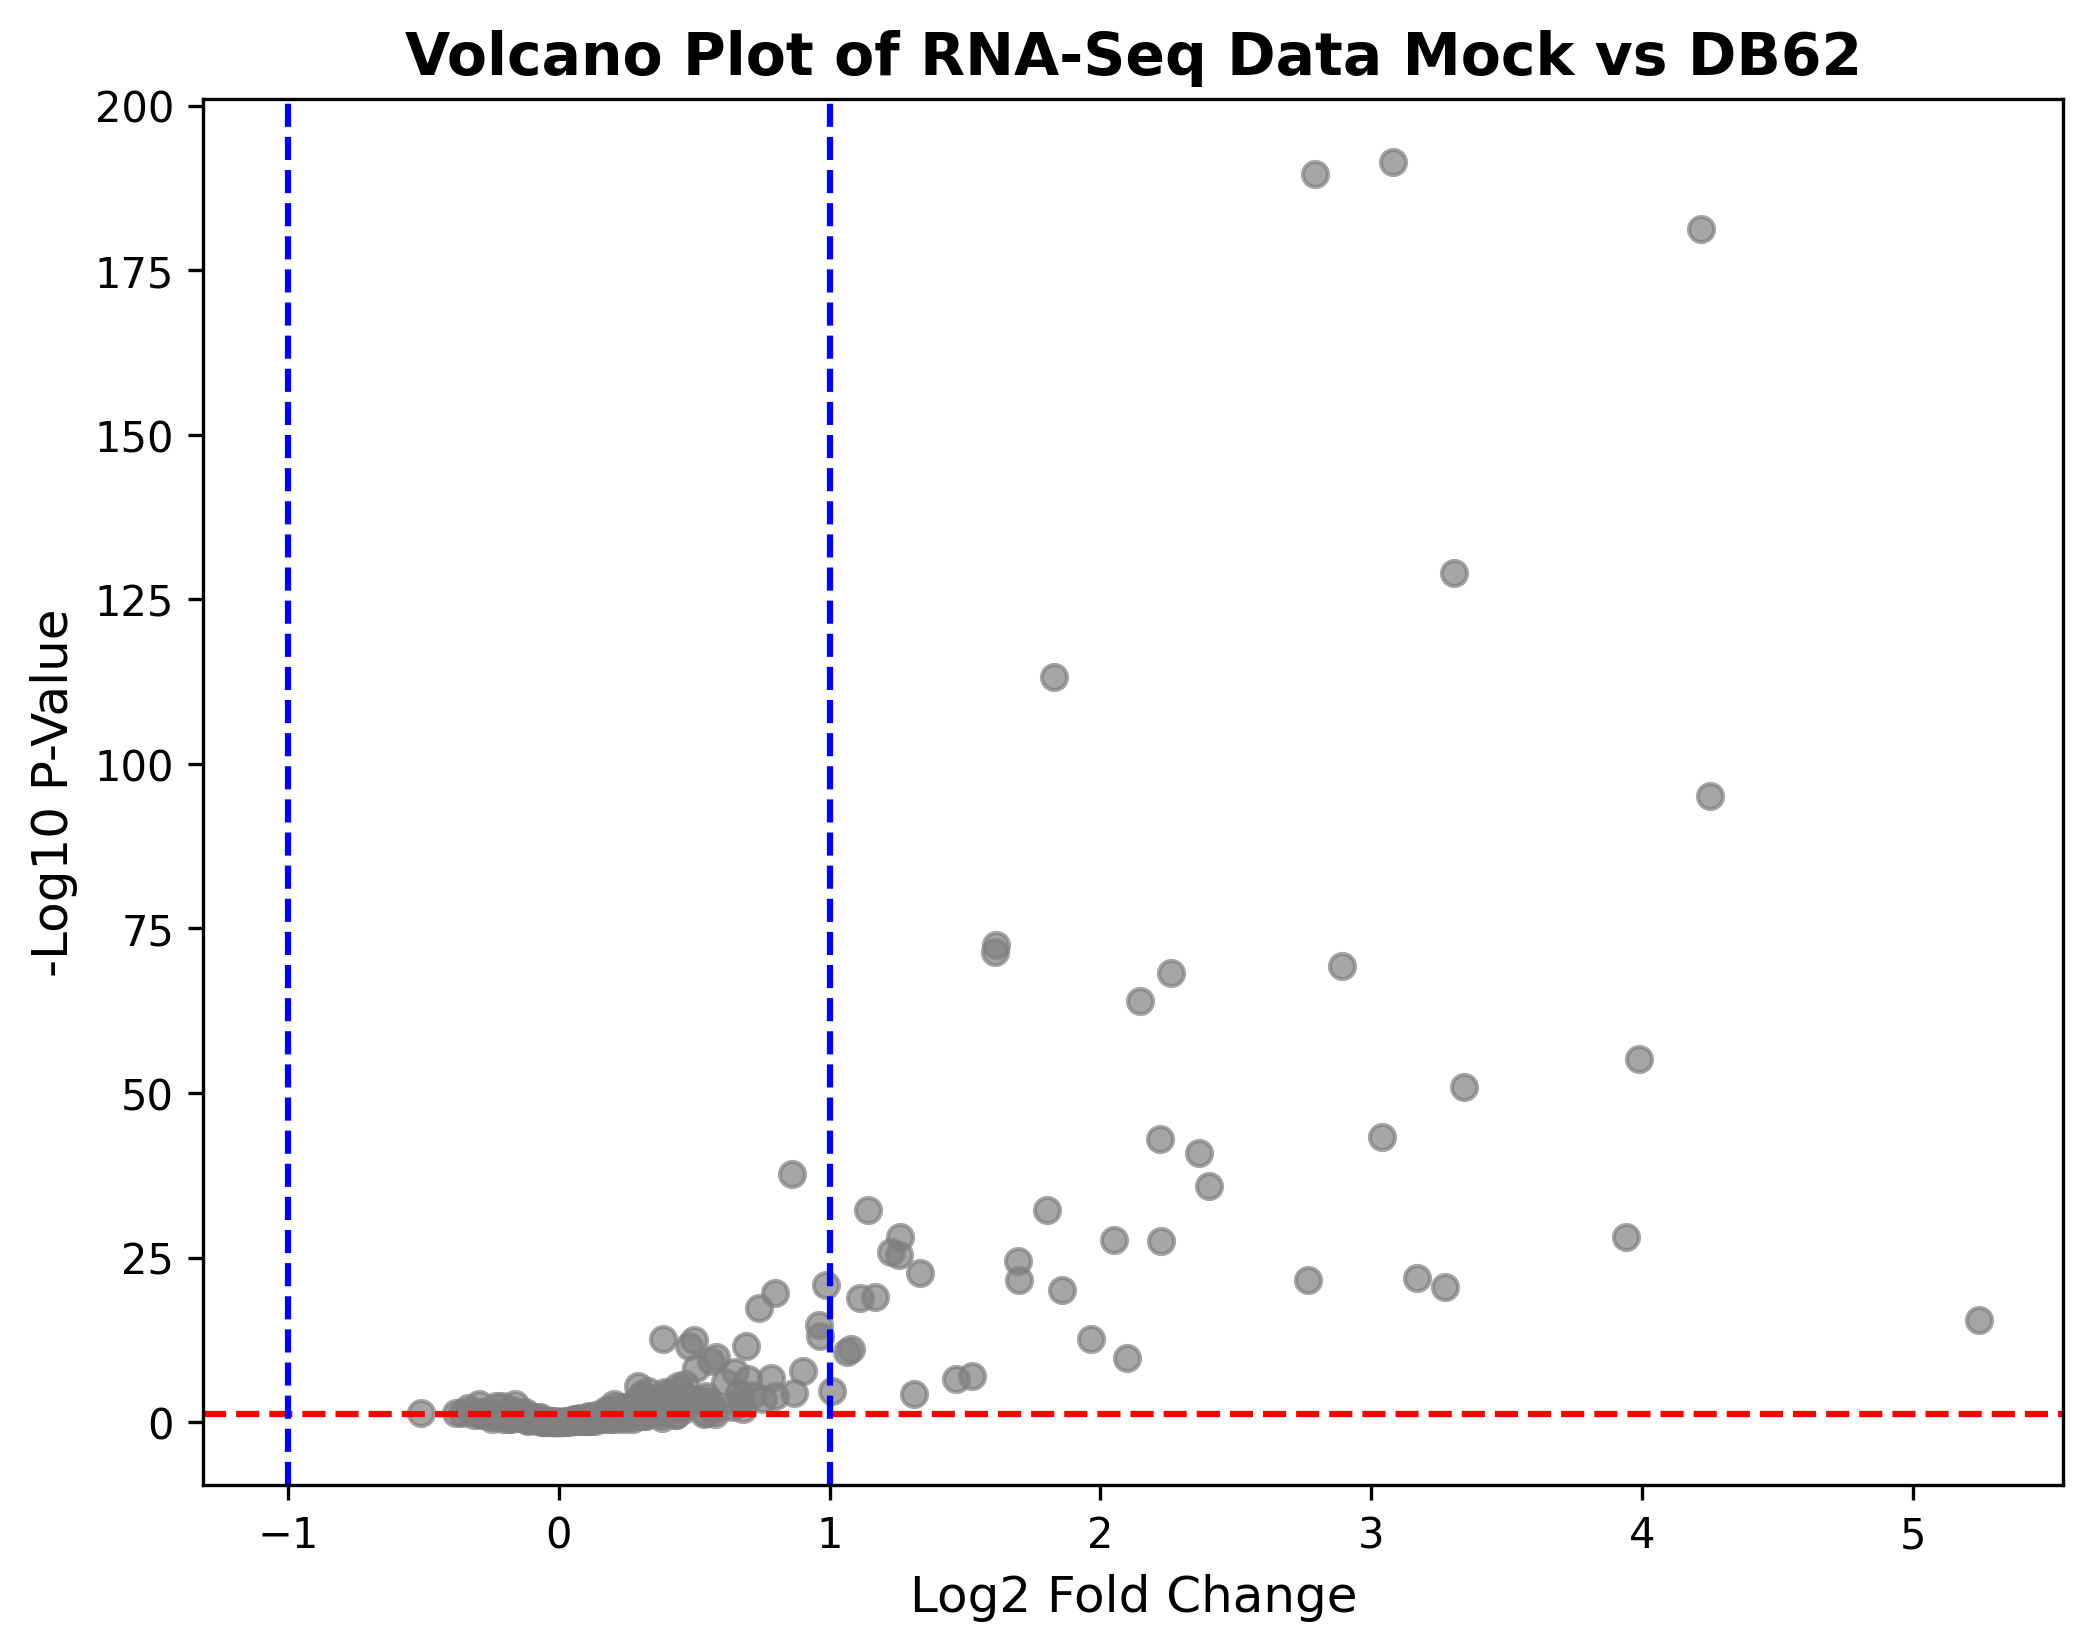

In [42]:
#set figure size and plot
plt.figure(figsize=(8,6), dpi=300)
volcanononsigfullfinal["NegLog10Pvalue"] = -np.log10(volcanononsigfullfinal["pvalue"])
plt.scatter(volcanononsigfullfinal["log2FoldChange"], volcanononsigfullfinal["NegLog10Pvalue"], color = 'gray', alpha=0.7)
plt.xlabel("Log2 Fold Change", fontsize=12)
plt.ylabel("-Log10 P-Value", fontsize=12)
plt.title("Volcano Plot of RNA-Seq Data Mock vs DB62", fontsize=14, fontweight='bold')
plt.axhline(y=1.3, linestyle='--', color='red')
plt.axvline(x=1, linestyle='--', color='blue')
plt.axvline(x=-1, linestyle='--', color='blue')
plt.show()

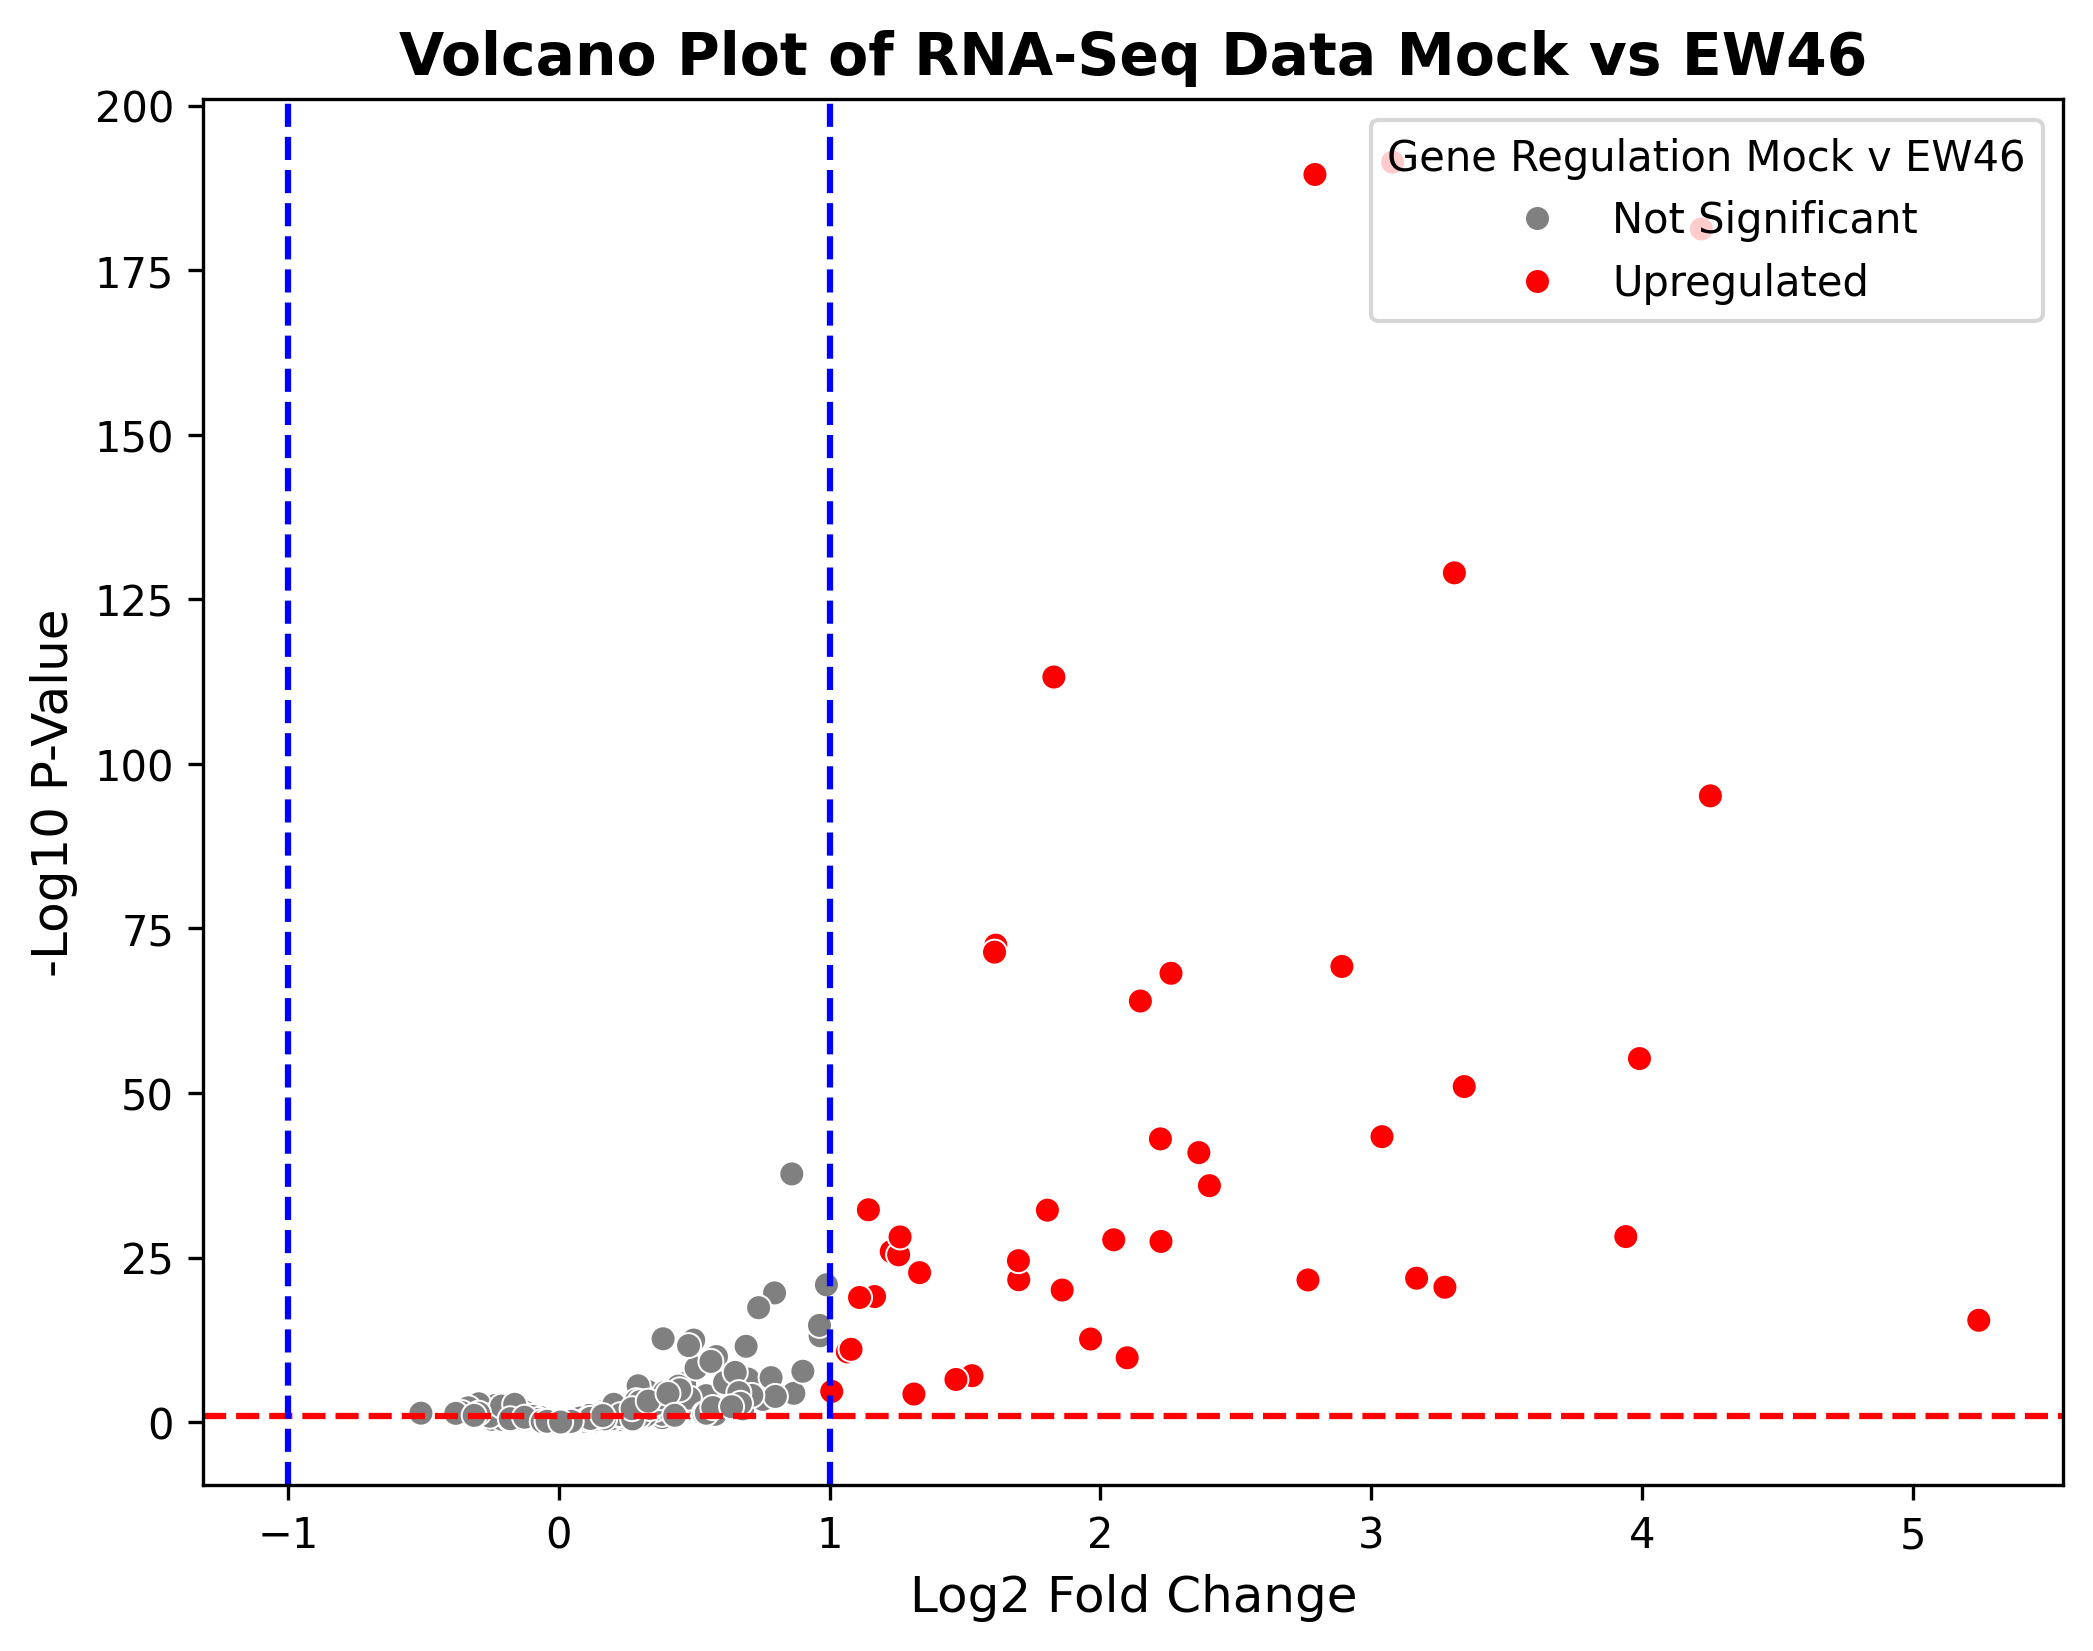

In [43]:
significant_genes = (volcanononsigfullfinal["pvalue"] < 0.05) & (abs(volcanononsigfullfinal["log2FoldChange"]) > 1)

# Calculate NegLog10Pvalue
volcanononsigfullfinal["NegLog10Pvalue"] = -np.log10(volcanononsigfullfinal["pvalue"])

# Assign regulation status based on criteria
volcanononsigfullfinal["Regulation"] = "Not Significant" # Default
volcanononsigfullfinal.loc[(volcanononsigfullfinal["pvalue"] < 0.05) & (volcanononsigfullfinal["log2FoldChange"] > 1), "Regulation"] = "Upregulated"
volcanononsigfullfinal.loc[(volcanononsigfullfinal["pvalue"] < 0.05) & (volcanononsigfullfinal["log2FoldChange"] < -1), "Regulation"] = "Downregulated"

# Define the palette to map regulation labels to colors
regulation_palette = {
    "Upregulated": "red",
    "Downregulated": "blue",
    "Not Significant": "gray"
}

#Set figure size and plot
plt.figure(figsize=(8,6), dpi=300)
sns.scatterplot(data=volcanononsigfullfinal, x="log2FoldChange", y="NegLog10Pvalue", hue="Regulation", palette=regulation_palette)
plt.xlabel("Log2 Fold Change", fontsize=12)
plt.ylabel("-Log10 P-Value", fontsize=12)
plt.title("Volcano Plot of RNA-Seq Data Mock vs EW46", fontsize=14, fontweight='bold')
plt.axhline(y=1, linestyle='--', color='red')
plt.axvline(x=1, linestyle='--', color='blue')
plt.axvline(x=-1, linestyle='--', color='blue')
# Let seaborn handle the legend labels automatically from the 'Regulation' column
plt.legend(title="Gene Regulation Mock v EW46", loc="upper right")
plt.savefig("volcano_plotDB62vEW46.png", dpi=600, bbox_inches="tight")
plt.show()

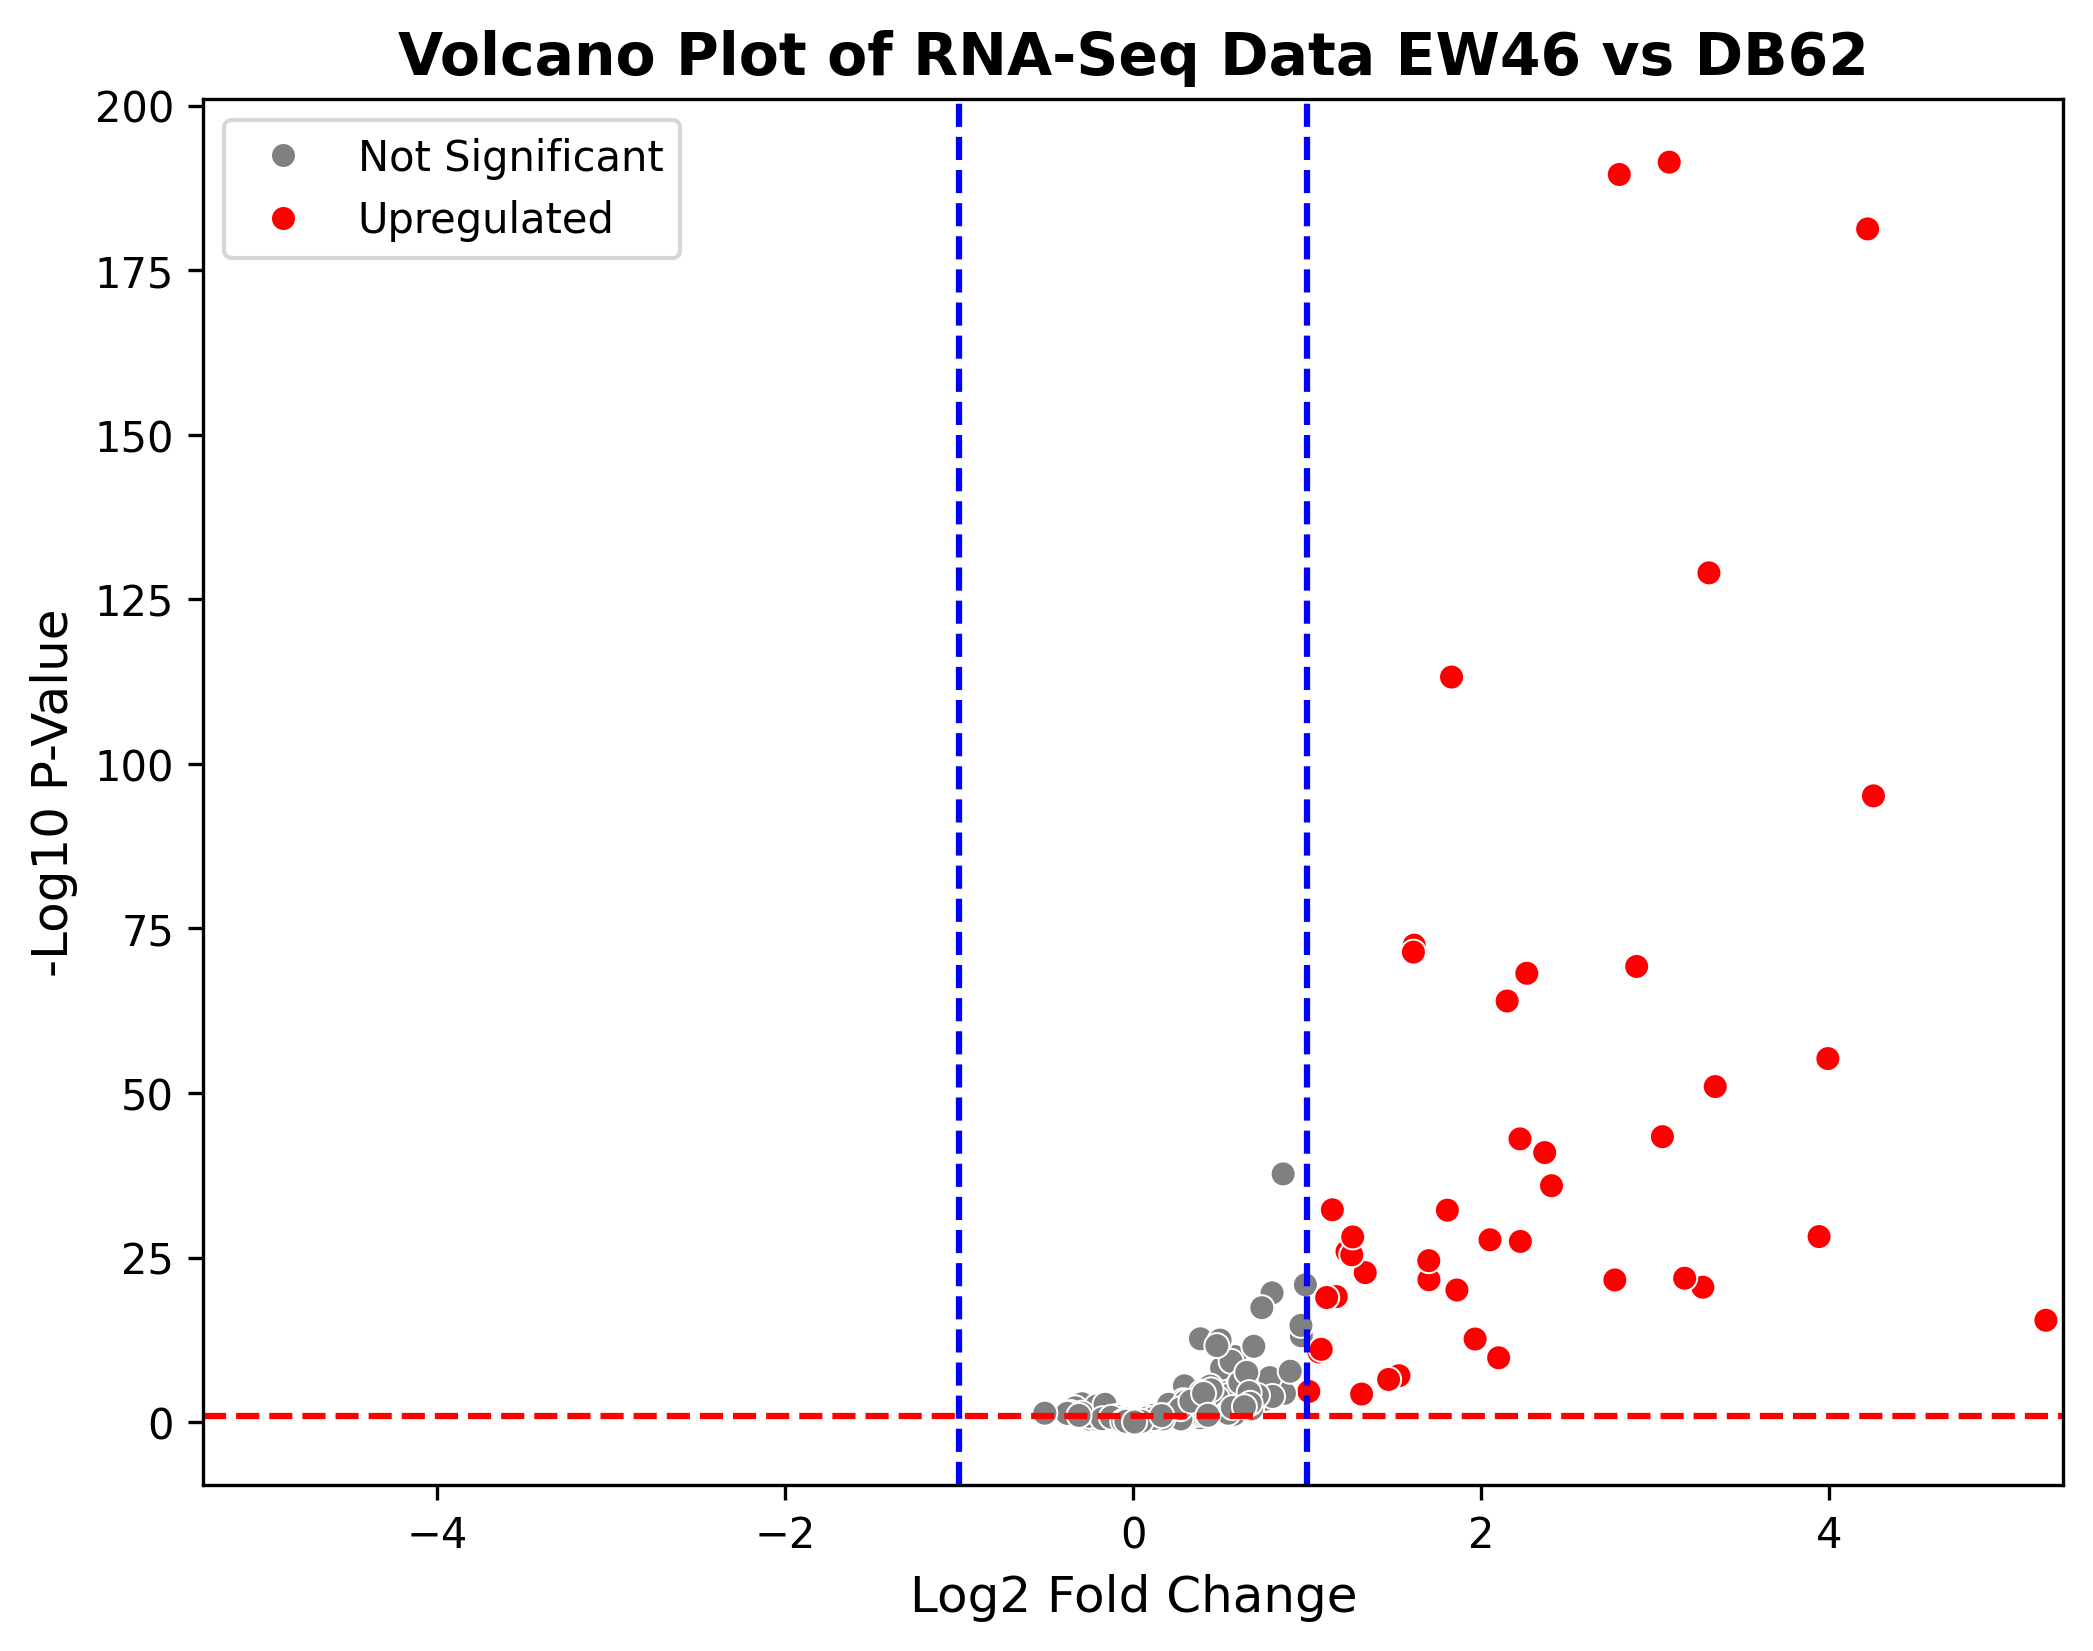

In [44]:
significant_genes = (volcanononsigfullfinal["pvalue"] < 0.05) & (abs(volcanononsigfullfinal["log2FoldChange"]) > 1)

# Calculate NegLog10Pvalue
volcanononsigfullfinal["NegLog10Pvalue"] = -np.log10(volcanononsigfullfinal["pvalue"])

# Assign regulation status based on criteria
volcanononsigfullfinal["Regulation"] = "Not Significant" # Default
volcanononsigfullfinal.loc[(volcanononsigfullfinal["pvalue"] < 0.05) & (volcanononsigfullfinal["log2FoldChange"] > 1), "Regulation"] = "Upregulated"
volcanononsigfullfinal.loc[(volcanononsigfullfinal["pvalue"] < 0.05) & (volcanononsigfullfinal["log2FoldChange"] < -1), "Regulation"] = "Downregulated"

# Define the palette to map regulation labels to colors
regulation_palette = {
    "Upregulated": "red",
    "Downregulated": "blue",
    "Not Significant": "gray"
}

#Set figure size and plot
plt.figure(figsize=(8,6), dpi=300)
sns.scatterplot(data=volcanononsigfullfinal, x="log2FoldChange", y="NegLog10Pvalue", hue="Regulation", palette=regulation_palette)
plt.xlabel("Log2 Fold Change", fontsize=12)
plt.ylabel("-Log10 P-Value", fontsize=12)
plt.title("Volcano Plot of RNA-Seq Data EW46 vs DB62", fontsize=14, fontweight='bold')
plt.axhline(y=1, linestyle='--', color='red')
plt.axvline(x=1, linestyle='--', color='blue')
plt.axvline(x=-1, linestyle='--', color='blue')
# Let seaborn handle the legend labels automatically from the 'Regulation' column
plt.legend(loc="upper left")
#plt.savefig("volcano_plotDB62vEW46.png", dpi=600, bbox_inches="tight")
#Set Horizontal Axis to be Equal
max_abs_log2FoldChange = (volcanononsigfullfinal['log2FoldChange'].abs().max() + 0.1)
plt.xlim(-max_abs_log2FoldChange, max_abs_log2FoldChange)
plt.show()
#title="EW46 vs DB62"

In [45]:
from adjustText import adjust_text

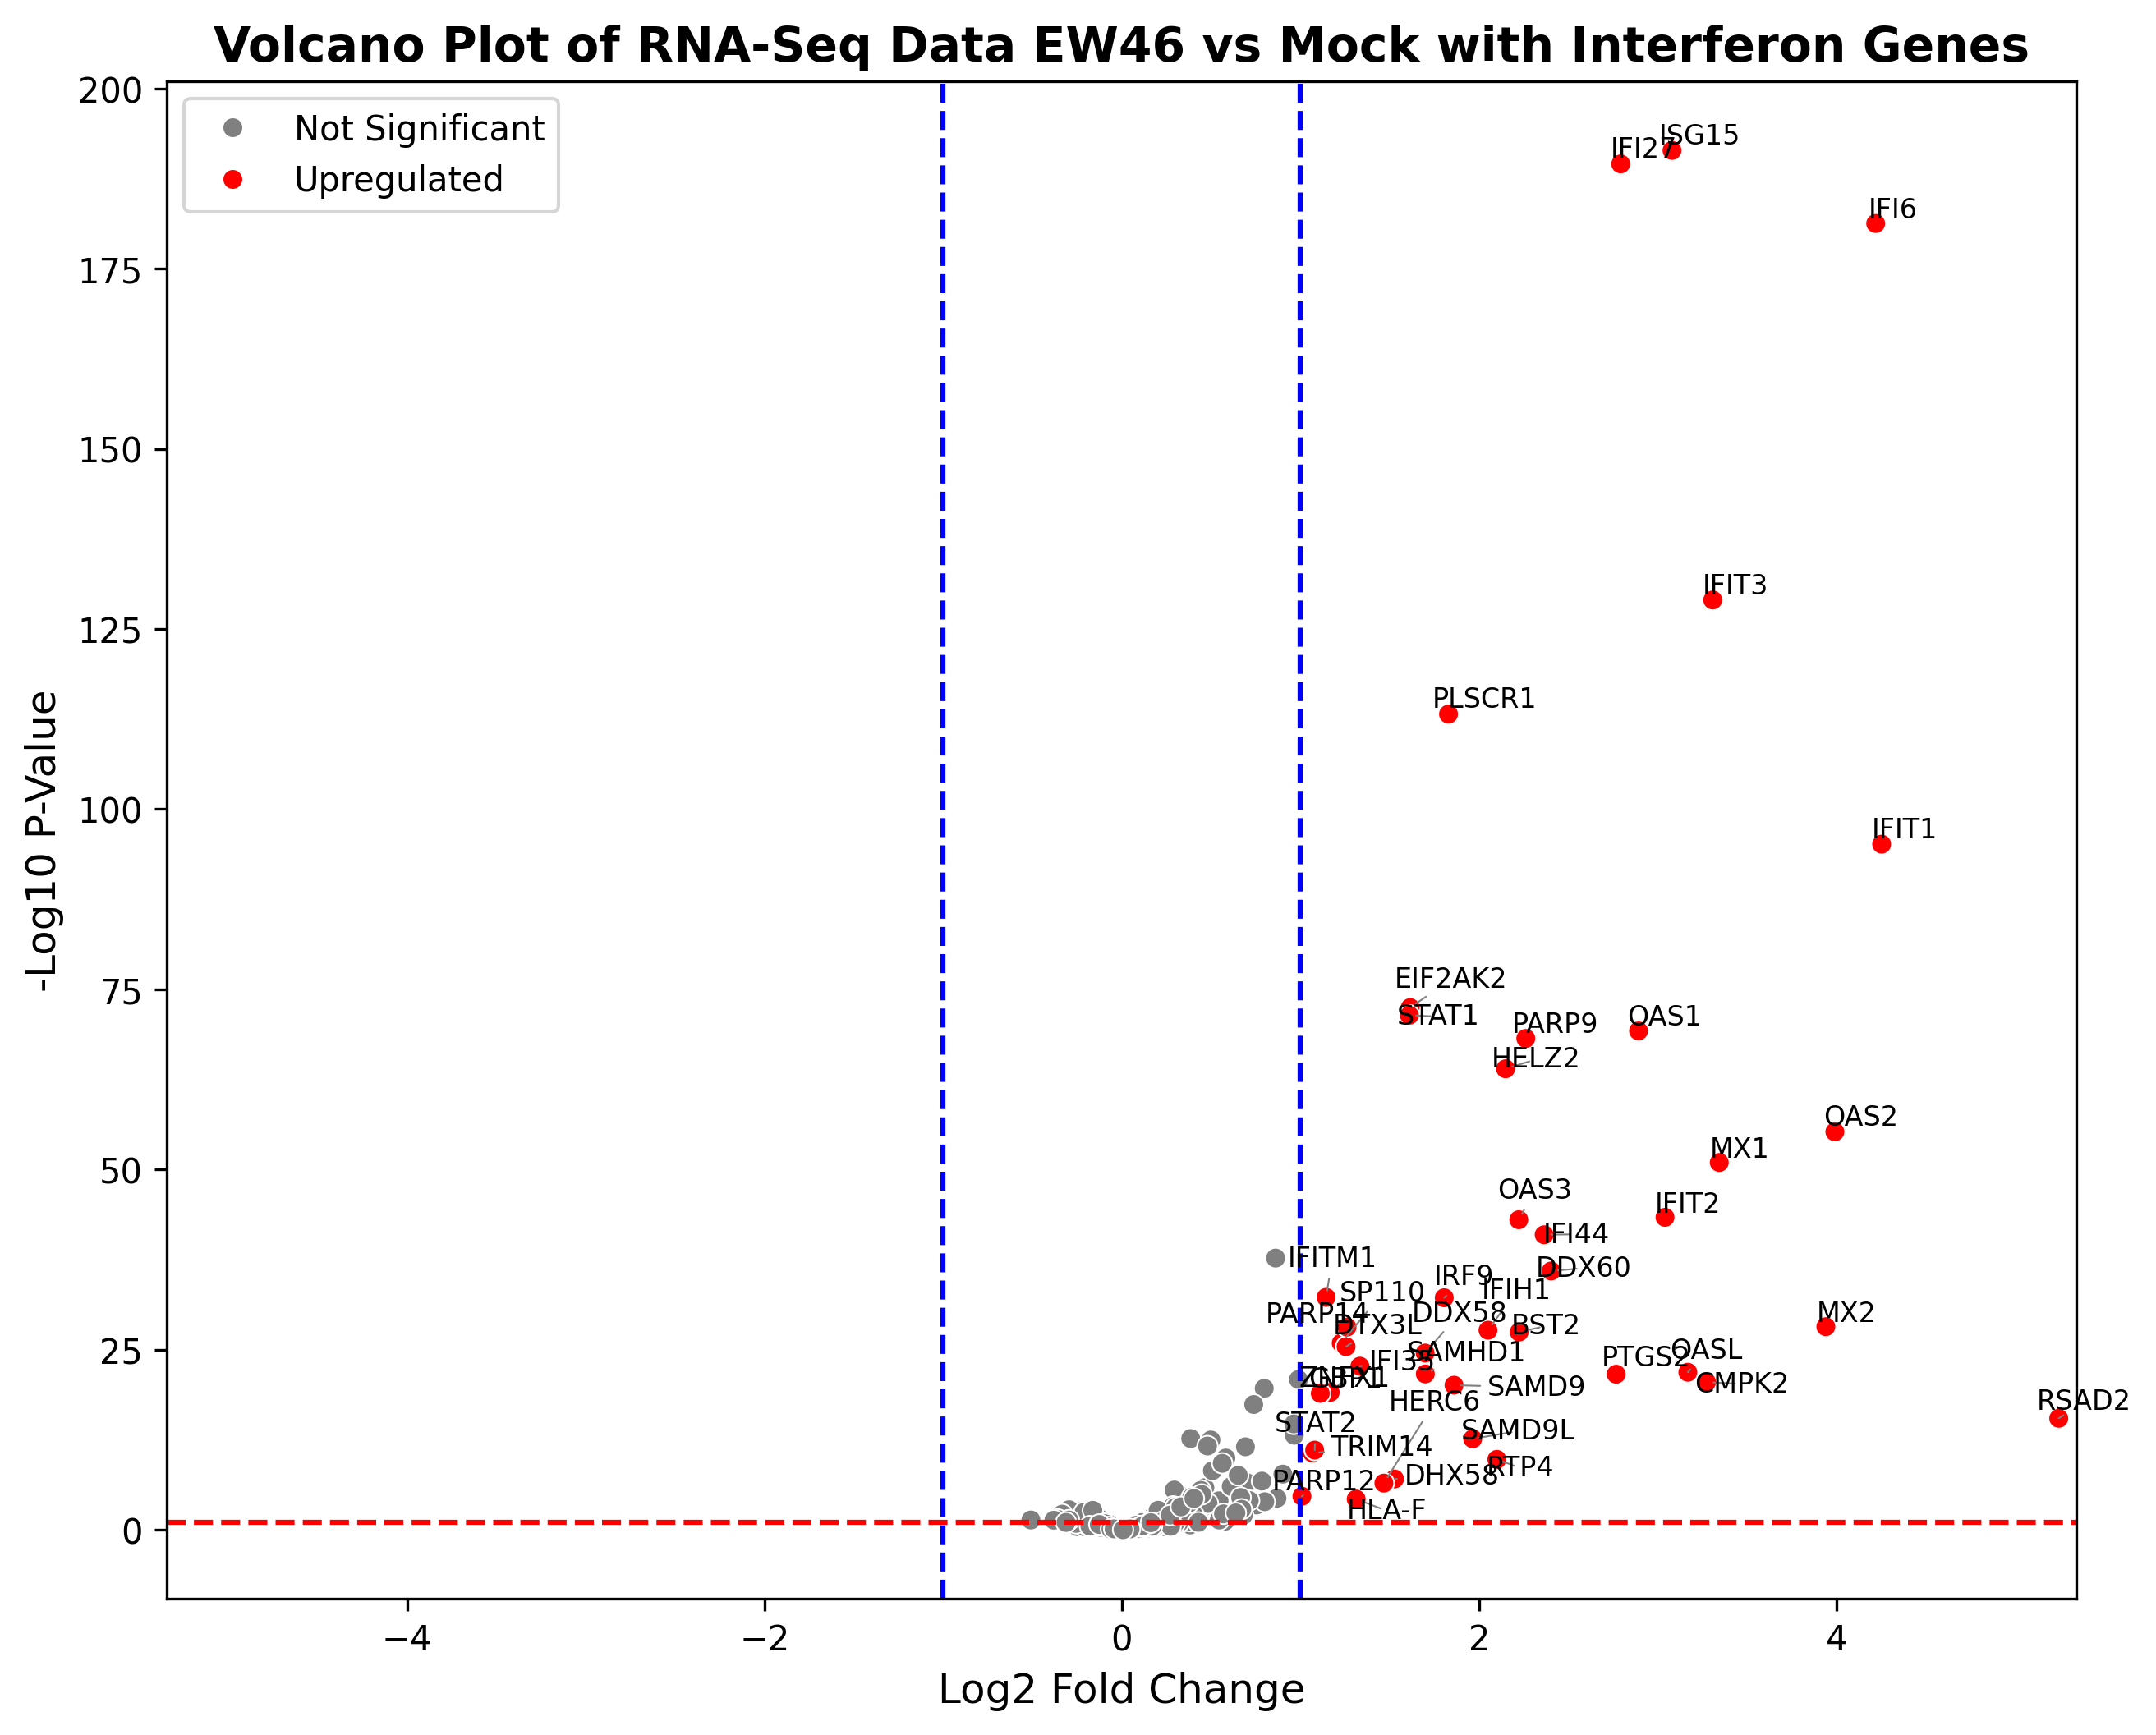

In [75]:
fig, ax = plt.figure(figsize=(10,8), dpi=300), plt.gca()
sns.scatterplot(data=volcanononsigfullfinal, x="log2FoldChange", y="NegLog10Pvalue", hue="Regulation", palette=regulation_palette, ax=ax)

plt.xlabel("Log2 Fold Change", fontsize=12)
plt.ylabel("-Log10 P-Value", fontsize=12)
plt.title("Volcano Plot of RNA-Seq Data EW46 vs Mock with Interferon Genes", fontsize=14, fontweight='bold')
plt.axhline(y=1, linestyle='--', color='red')
plt.axvline(x=1, linestyle='--', color='blue')
plt.axvline(x=-1, linestyle='--', color='blue')
plt.legend(loc="upper left")

# Filter for significant genes with 'Upregulated' or 'Downregulated' status
significant_labeled_genes = volcanononsigfullfinal[(volcanononsigfullfinal['Regulation'] == 'Upregulated') | (volcanononsigfullfinal['Regulation'] == 'Downregulated')]

# Create list of texts to adjust
texts = []
for i, row in significant_labeled_genes.iterrows():
    texts.append(plt.text(row['log2FoldChange'], row['NegLog10Pvalue'], row['Gene'], fontsize=8))

# Adjust text to prevent overlapping
adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

max_abs_log2FoldChange = (volcanononsigfullfinal['log2FoldChange'].abs().max() + 0.1)
plt.xlim(-max_abs_log2FoldChange, max_abs_log2FoldChange)
plt.savefig("volcano_plot_labeled_DB62vEW46.png", dpi=600, bbox_inches="tight")
plt.show()

In [47]:
#This volcano plot shows EW46 genes and if they are upregulated or downregulated compared to Mock.

# Heatmap with only significant genes

In [48]:
dds.layers["normed_counts"]

array([[ 207.89474391, 1619.02934998,   74.52830442, ...,   23.53525403,
         279.48114158,  251.04270963],
       [ 236.8879448 , 1842.05529275,   67.68226994, ...,   31.09725916,
         214.02231306,  214.02231306],
       [ 195.73300217, 1973.64110523,   72.85617303, ...,   28.27254476,
         225.0929525 ,  250.10328055],
       [ 178.27004486, 1935.50334419,   71.97237836, ...,   28.78895134,
         243.59881906,  219.23893716],
       [ 227.27467172, 1672.30489893,   58.55548311, ...,   21.83424794,
         244.14659059,  222.31234265],
       [ 156.0963283 , 1745.35777609,   70.28898994, ...,   19.16972453,
         232.77522641,  205.38990566]])

In [49]:
dds.layers["log1p"] = np.log1p(dds.layers["normed_counts"])

In [50]:
dds.layers["log1p"]

array([[5.34183051, 7.39019955, 4.32450748, ..., 3.20011102, 5.63650649,
        5.52959856],
       [5.47179974, 7.51917996, 4.22949109, ..., 3.46877064, 5.3707418 ,
        5.3707418 ],
       [5.28184749, 7.58814194, 4.30211959, ..., 3.37665004, 5.42094621,
        5.52586433],
       [5.1888933 , 7.56863923, 4.29008099, ..., 3.39413756, 5.4996194 ,
        5.39471303],
       [5.4305496 , 7.42255593, 4.08690837, ..., 3.12826151, 5.50185636,
        5.40857143],
       [5.05685917, 7.46528763, 4.2667419 , ..., 3.00418269, 5.45436008,
        5.32976713]])

In [51]:
#This is the dataframe where we'll use all the remaining genes
cleanedsigs

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Symbol
gene_id,,,,,,,
ENSG00000055332,1025.625072,1.613955,0.089190,18.095629,3.449851e-73,3.582325e-70,EIF2AK2
ENSG00000059378,95.287971,1.008233,0.237317,4.248468,2.152377e-05,6.459618e-04,PARP12
ENSG00000068079,355.159654,1.332627,0.133572,9.976823,1.925332e-23,4.543783e-21,IFI35
ENSG00000073756,82.628921,2.766809,0.284695,9.718512,2.514277e-22,5.554948e-20,PTGS2
ENSG00000089127,362.226324,2.892141,0.163580,17.680246,5.953620e-70,4.755568e-67,OAS1
ENSG00000101347,204.141243,1.698723,0.174640,9.727016,2.312779e-22,5.220848e-20,SAMHD1
ENSG00000106785,253.797049,1.065932,0.159124,6.698736,2.102302e-11,2.040215e-09,TRIM14
ENSG00000107201,248.673660,1.697653,0.163487,10.384006,2.932087e-25,7.611699e-23,DDX58
ENSG00000108771,83.800188,1.526254,0.285154,5.352385,8.680249e-08,5.035514e-06,DHX58


In [52]:
dds_sigs1 = dds[:,cleanedsigs.index]
dds_sigs1

View of AnnData object with n_obs × n_vars = 6 × 43
    obs: 'Condition', 'size_factors', 'replaceable'
    var: '_normed_means', 'non_zero', '_MoM_dispersions', 'genewise_dispersions', '_genewise_converged', 'fitted_dispersions', 'MAP_dispersions', '_MAP_converged', 'dispersions', '_outlier_genes', '_LFC_converged', 'replaced', 'refitted', '_pvalue_cooks_outlier'
    uns: 'trend_coeffs', 'disp_function_type', '_squared_logres', 'prior_disp_var'
    obsm: 'design_matrix', '_mu_LFC', '_hat_diagonals'
    varm: 'LFC'
    layers: 'normed_counts', '_mu_hat', 'cooks', 'log1p'

In [53]:
heatmapfull = pd.DataFrame(dds_sigs1.layers["log1p"].T, index=dds_sigs1.var_names, columns=dds_sigs1.obs_names)

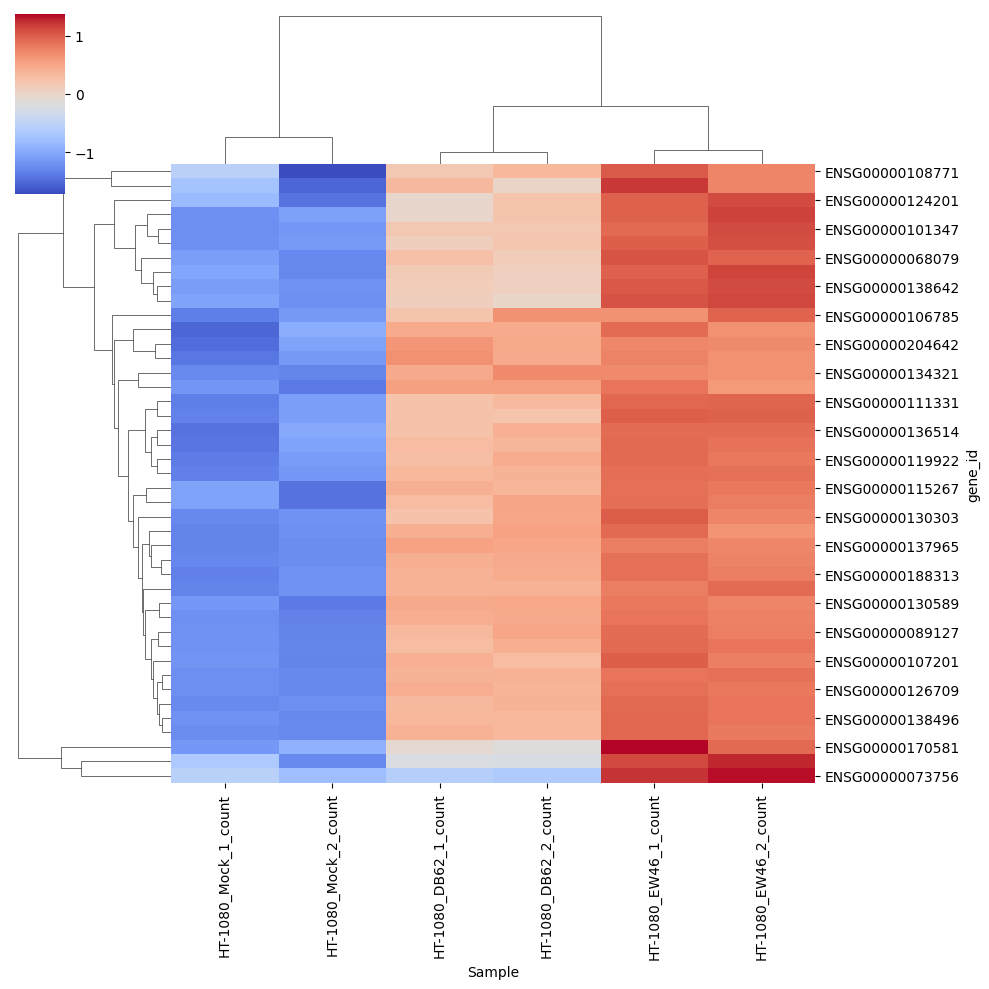

In [54]:
sns.clustermap(heatmapfull, z_score=0, cmap = "coolwarm")

In [55]:
heatmapfull.index = heatmapfull.index.map(mapper.mapper)

In [56]:
#if you want to make a CSV list of genes
#heatmapfull
#heatmapfull.to_csv('heatmap.csv')

'Mock V DB62'

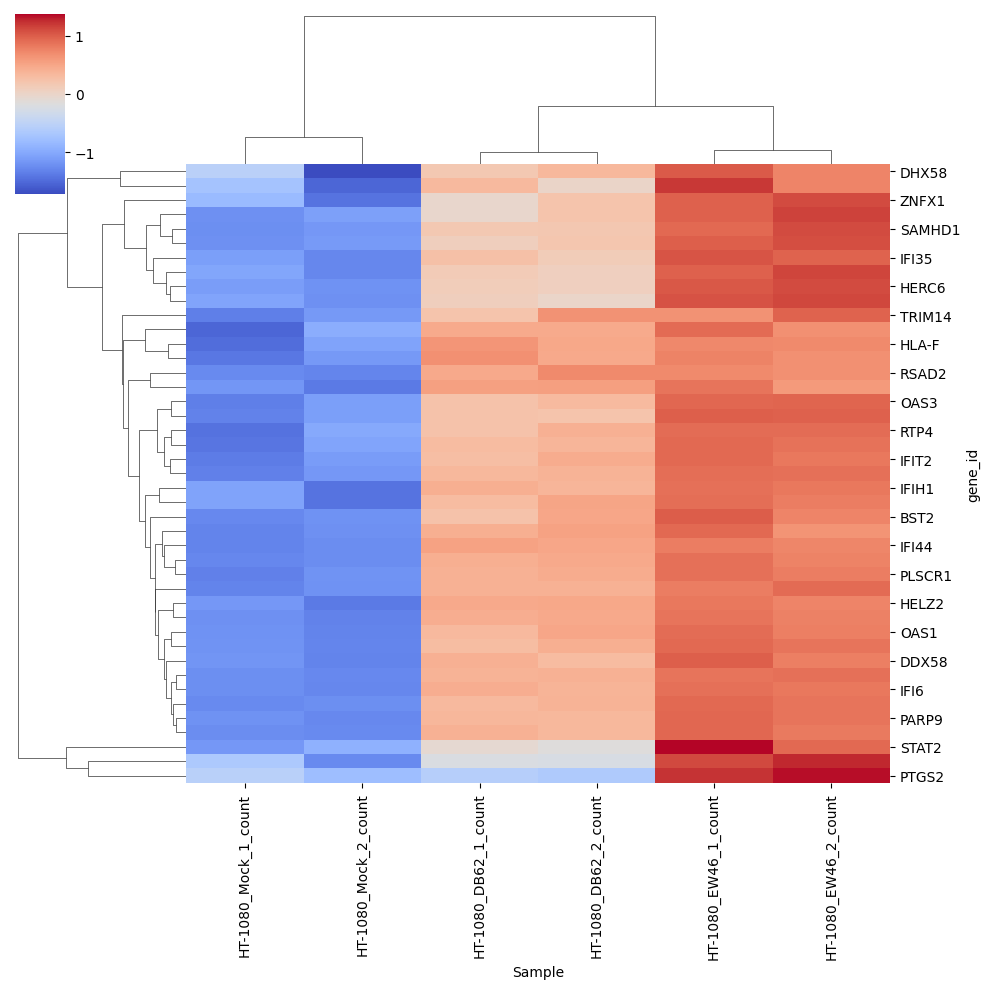

In [57]:
labeledheatmapfull = sns.clustermap(heatmapfull, z_score=0, cmap = "coolwarm", figsize=(10,10))
'''Mock V DB62'''

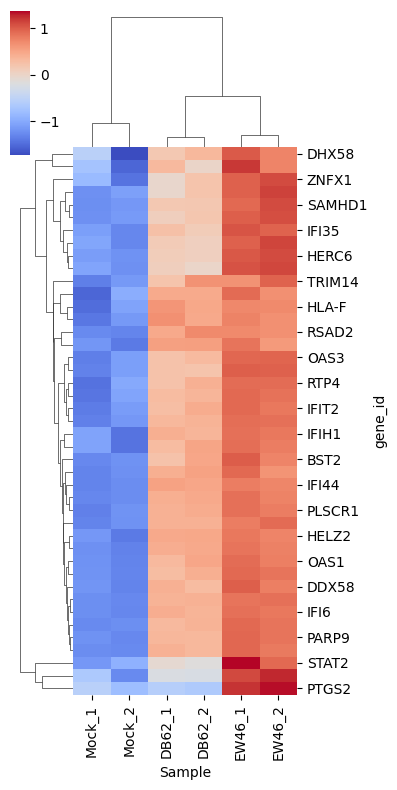

In [58]:
finalheatmapfull = pd.DataFrame(dds_sigs1.layers["log1p"].T, index=dds_sigs1.var_names, columns=dds_sigs1.obs_names)
finalheatmapfull.index = finalheatmapfull.index.map(mapper.mapper)

rename_map = {
    'HT-1080_Mock_1_count': 'Mock_1',
    'HT-1080_Mock_2_count': 'Mock_2',
    'HT-1080_DB62_1_count': 'DB62_1',
    'HT-1080_DB62_2_count': 'DB62_2',
    'HT-1080_EW46_1_count': 'EW46_1',
    'HT-1080_EW46_2_count': 'EW46_2'
}
finalheatmapfull.rename(columns=rename_map, inplace=True)

finallabeledheatmapfull = sns.clustermap(finalheatmapfull, z_score=0, cmap = "coolwarm", figsize=(4,8))
finallabeledheatmapfull

# Top 24 significant genes Heatmap

In [59]:
#should rank by log2fold change absolute value?

In [60]:
# Keep top 24 genes by lowest and highest log2foldchanges
top_12_lowest_lfc = cleanedsigs.nsmallest(12, 'log2FoldChange')
top_12_highest_lfc = cleanedsigs.nlargest(12, 'log2FoldChange')
top_24_genes_for_plots = pd.concat([top_12_lowest_lfc, top_12_highest_lfc])
top_24_genes_for_plots # Will use this dataframe for the top volcano plot as well

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Symbol
gene_id,,,,,,,
ENSG00000059378,95.287971,1.008233,0.237317,4.248468,2.152377e-05,6.459618e-04,PARP12
ENSG00000106785,253.797049,1.065932,0.159124,6.698736,2.102302e-11,2.040215e-09,TRIM14
ENSG00000170581,241.086330,1.079397,0.158077,6.828312,8.591937e-12,8.497016e-10,STAT2
ENSG00000124201,513.669512,1.110852,0.122438,9.072752,1.160479e-19,2.077658e-17,ZNFX1
ENSG00000185885,929.488666,1.143598,0.095584,11.964339,5.463058e-33,2.101052e-30,IFITM1
ENSG00000117228,391.054575,1.166383,0.128048,9.108926,8.320153e-20,1.515728e-17,GBP1
ENSG00000135899,507.243085,1.227998,0.114937,10.684121,1.207875e-26,3.300677e-24,SP110
ENSG00000163840,458.319247,1.255173,0.118662,10.577671,3.782421e-26,1.007094e-23,DTX3L
ENSG00000173193,514.039152,1.260545,0.113068,11.148544,7.278790e-29,2.290393e-26,PARP14


In [61]:
dds_sigs = dds[:,top_24_genes_for_plots.index]
dds_sigs

View of AnnData object with n_obs × n_vars = 6 × 24
    obs: 'Condition', 'size_factors', 'replaceable'
    var: '_normed_means', 'non_zero', '_MoM_dispersions', 'genewise_dispersions', '_genewise_converged', 'fitted_dispersions', 'MAP_dispersions', '_MAP_converged', 'dispersions', '_outlier_genes', '_LFC_converged', 'replaced', 'refitted', '_pvalue_cooks_outlier'
    uns: 'trend_coeffs', 'disp_function_type', '_squared_logres', 'prior_disp_var'
    obsm: 'design_matrix', '_mu_LFC', '_hat_diagonals'
    varm: 'LFC'
    layers: 'normed_counts', '_mu_hat', 'cooks', 'log1p'

In [62]:
smallheatmap = pd.DataFrame(dds_sigs.layers["log1p"].T, index=dds_sigs.var_names, columns=dds_sigs.obs_names)

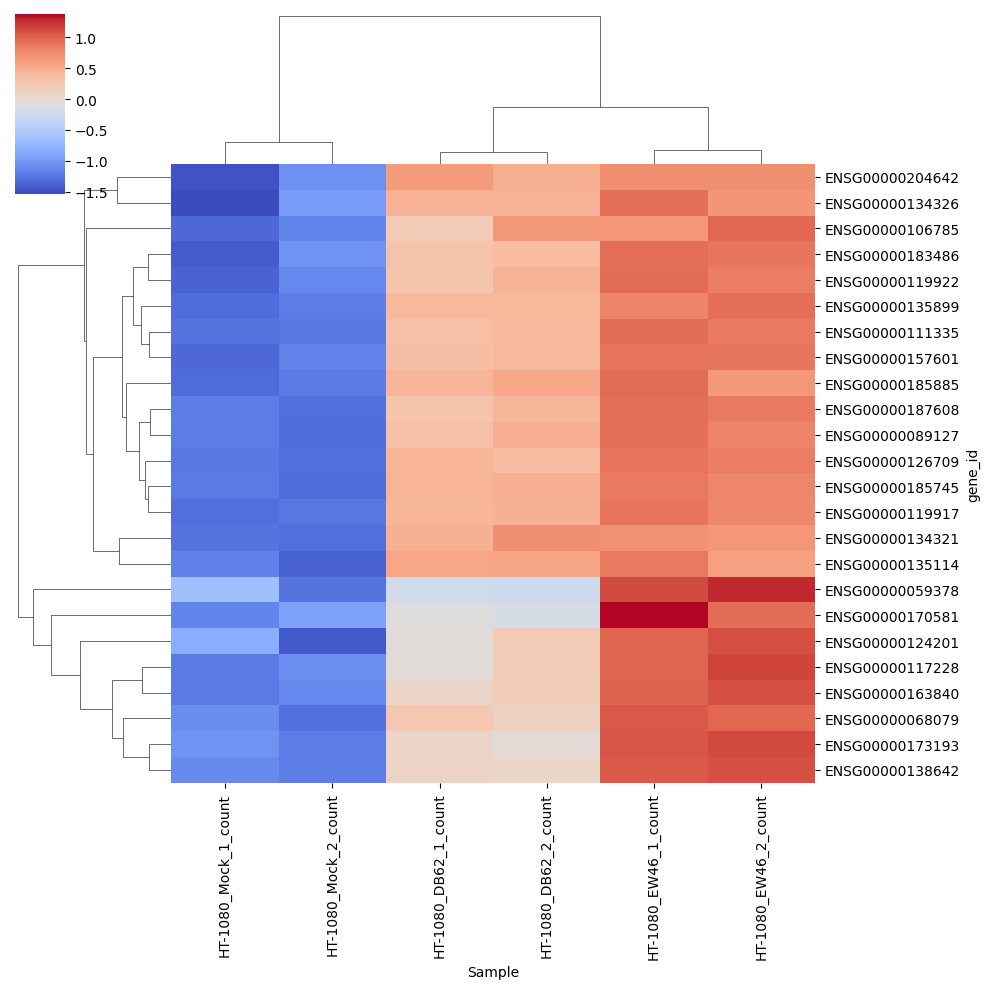

In [63]:
sns.clustermap(smallheatmap, z_score=0, cmap = "coolwarm")

In [64]:
smallheatmap.index = smallheatmap.index.map(mapper.mapper)

In [65]:
#smallheatmap
#smallheatmap.to_csv('smallheatmap.csv')
#again only neccesary if you want a csv

'Mock V DB62'

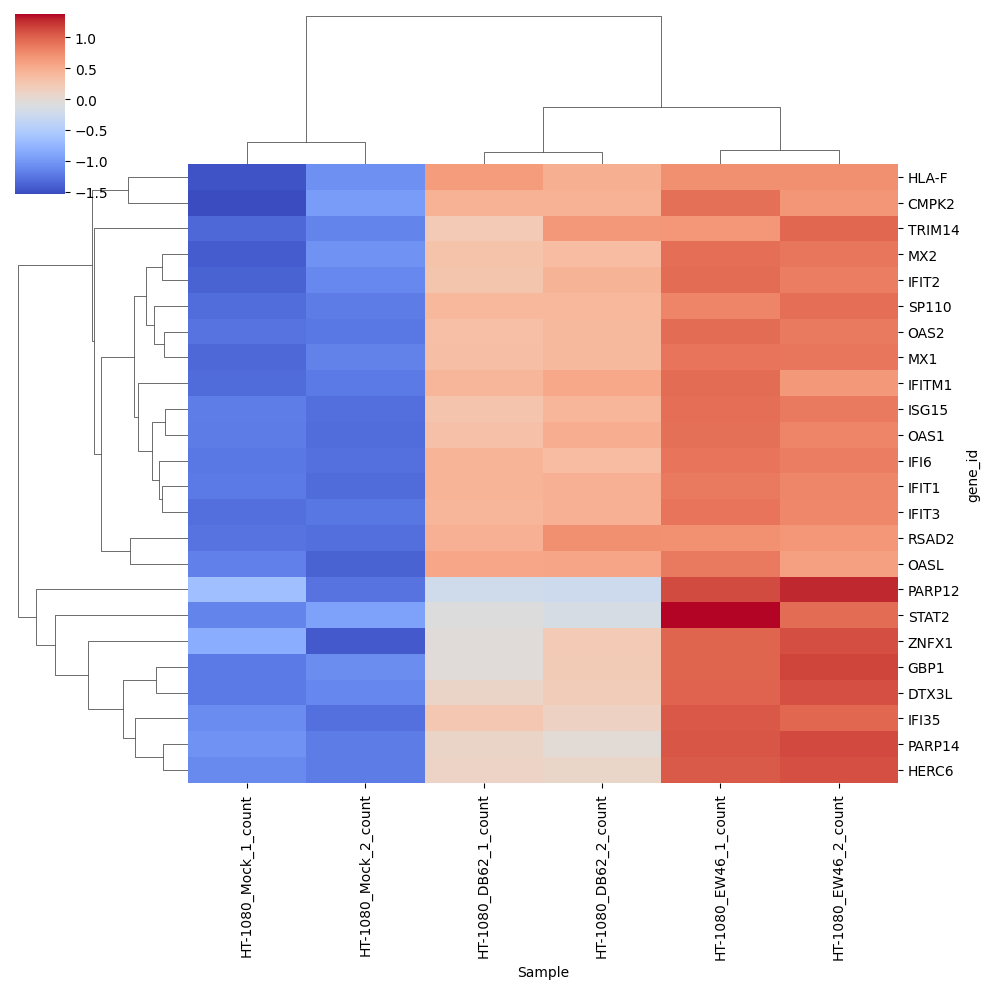

In [66]:
labeledheatmapsmall = sns.clustermap(smallheatmap, z_score=0, cmap = "coolwarm", figsize=(10,10))
'''Mock V DB62'''

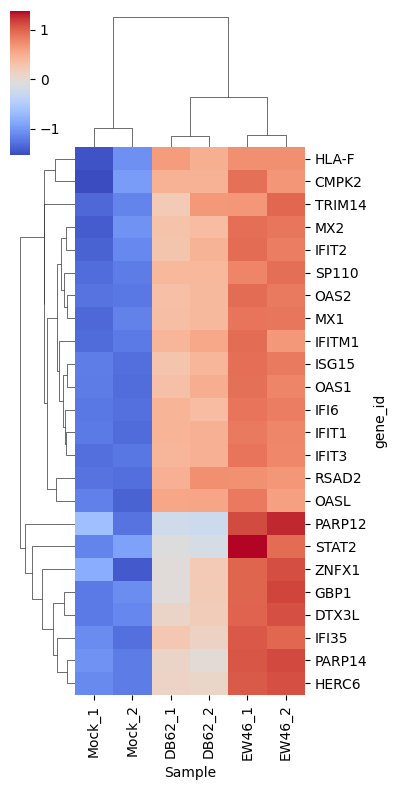

In [67]:
smallheatmap_1 = pd.DataFrame(dds_sigs.layers["log1p"].T, index=dds_sigs.var_names, columns=dds_sigs.obs_names)
smallheatmap_1.index = smallheatmap_1.index.map(mapper.mapper)

rename_map = {
    'HT-1080_Mock_1_count': 'Mock_1',
    'HT-1080_Mock_2_count': 'Mock_2',
    'HT-1080_DB62_1_count': 'DB62_1',
    'HT-1080_DB62_2_count': 'DB62_2',
    'HT-1080_EW46_1_count': 'EW46_1',
    'HT-1080_EW46_2_count': 'EW46_2'
}
smallheatmap_1.rename(columns=rename_map, inplace=True)

smallheatmaplabeledfinal = sns.clustermap(smallheatmap_1, z_score=0, cmap = "coolwarm", figsize=(4,8))
smallheatmaplabeledfinal

## Ranking by absolute log2fold change to see if a diff appears

In [68]:
cleanedsigs['abs_log2FoldChange'] = cleanedsigs['log2FoldChange'].abs()
top_24_genes_by_abs_lfc = cleanedsigs.nlargest(24, 'abs_log2FoldChange')
top_24_genes_by_abs_lfc

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Symbol,abs_log2FoldChange
gene_id,,,,,,,,
ENSG00000134321,67.978441,5.243846,0.642593,8.160452,3.337739e-16,4.747819e-14,RSAD2,5.243846
ENSG00000185745,363.710748,4.252774,0.204704,20.775226,7.252166e-96,1.075807e-92,IFIT1,4.252774
ENSG00000126709,728.231319,4.219350,0.146671,28.767515,5.470094e-182,1.893382e-178,IFI6,4.219350
ENSG00000111335,192.669181,3.990909,0.253231,15.759951,5.867828e-56,3.584208e-53,OAS2,3.990909
ENSG00000183486,93.837107,3.940398,0.353092,11.159688,6.421640e-29,2.083822e-26,MX2,3.940398
ENSG00000157601,197.372056,3.343847,0.221033,15.128302,1.053794e-51,5.759263e-49,MX1,3.343847
ENSG00000119917,635.919268,3.307434,0.136475,24.234638,9.601774e-130,2.492621e-126,IFIT3,3.307434
ENSG00000134326,84.204234,3.272455,0.346057,9.456393,3.187503e-21,6.365198e-19,CMPK2,3.272455
ENSG00000135114,96.261955,3.167965,0.323881,9.781264,1.355079e-22,3.126919e-20,OASL,3.167965


In [69]:
dds_sigs = dds[:,top_24_genes_by_abs_lfc.index]
dds_sigs

View of AnnData object with n_obs × n_vars = 6 × 24
    obs: 'Condition', 'size_factors', 'replaceable'
    var: '_normed_means', 'non_zero', '_MoM_dispersions', 'genewise_dispersions', '_genewise_converged', 'fitted_dispersions', 'MAP_dispersions', '_MAP_converged', 'dispersions', '_outlier_genes', '_LFC_converged', 'replaced', 'refitted', '_pvalue_cooks_outlier'
    uns: 'trend_coeffs', 'disp_function_type', '_squared_logres', 'prior_disp_var'
    obsm: 'design_matrix', '_mu_LFC', '_hat_diagonals'
    varm: 'LFC'
    layers: 'normed_counts', '_mu_hat', 'cooks', 'log1p'

In [70]:
rankedsmallheatmap = pd.DataFrame(dds_sigs.layers["log1p"].T, index=dds_sigs.var_names, columns=dds_sigs.obs_names)

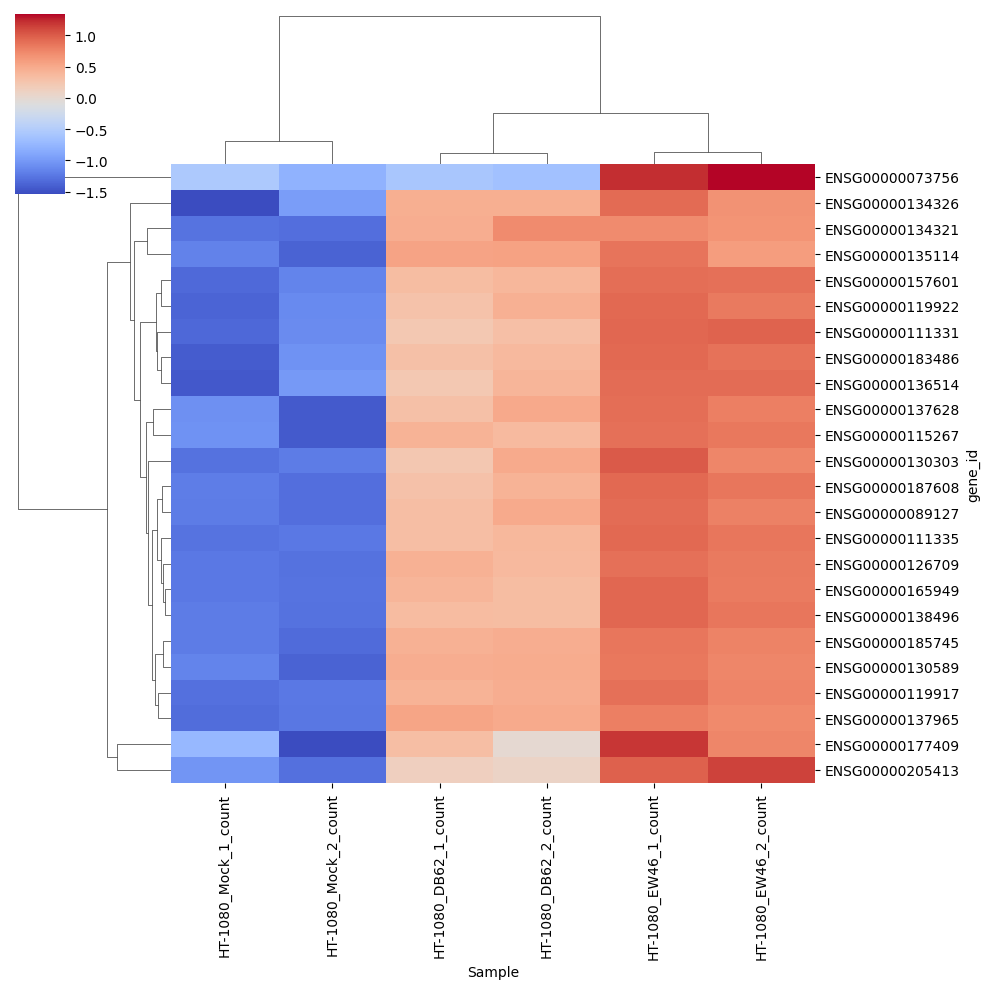

In [71]:
sns.clustermap(rankedsmallheatmap, z_score=0, cmap = "coolwarm")

In [72]:
rankedsmallheatmap.index = rankedsmallheatmap.index.map(mapper.mapper)

'Mock V DB62'

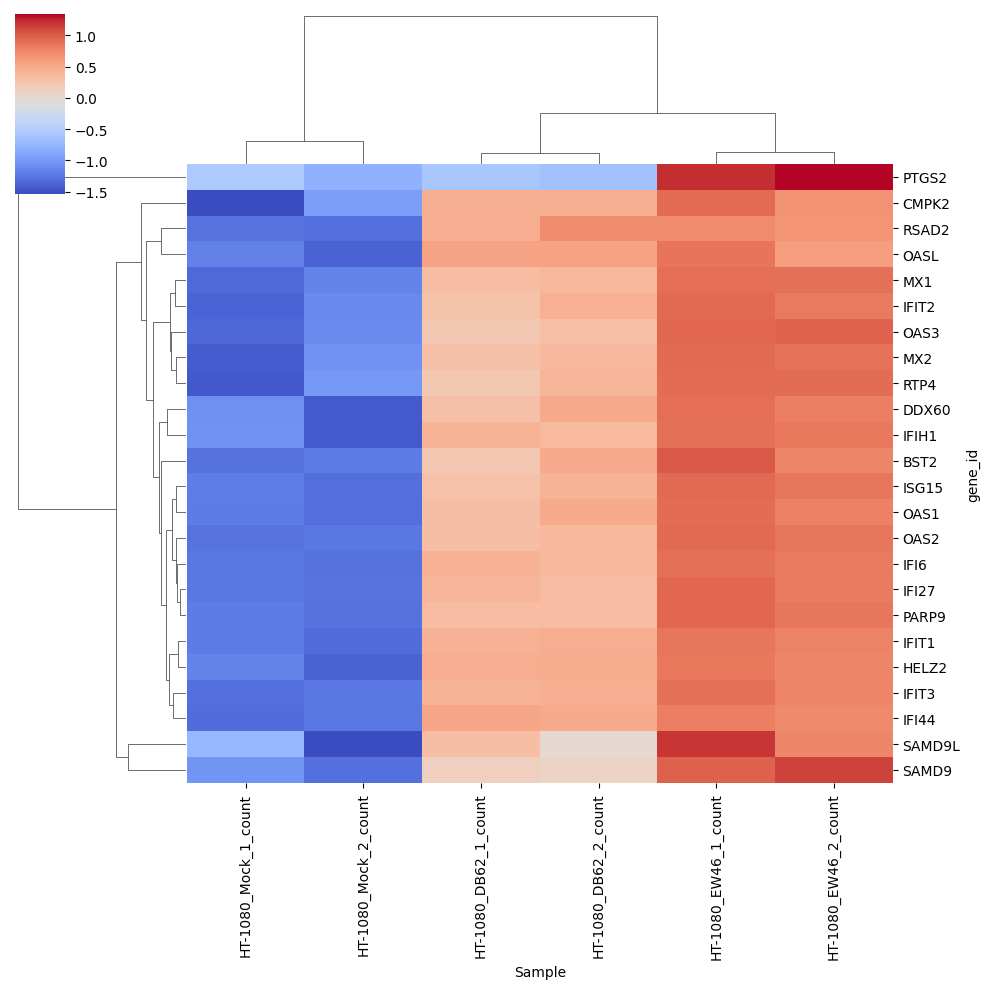

In [73]:
ranklabeledheatmapsmall = sns.clustermap(rankedsmallheatmap, z_score=0, cmap = "coolwarm", figsize=(10,10))
'''Mock V DB62'''

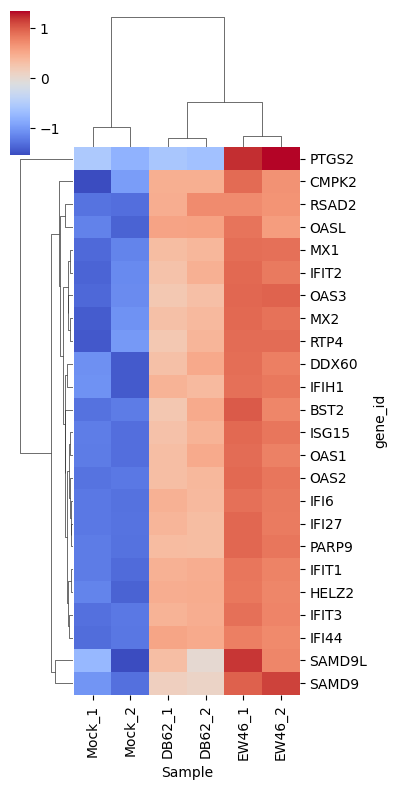

In [74]:
ranksmallheatmap_1 = pd.DataFrame(dds_sigs.layers["log1p"].T, index=dds_sigs.var_names, columns=dds_sigs.obs_names)
ranksmallheatmap_1.index = ranksmallheatmap_1.index.map(mapper.mapper)

rename_map = {
    'HT-1080_Mock_1_count': 'Mock_1',
    'HT-1080_Mock_2_count': 'Mock_2',
    'HT-1080_DB62_1_count': 'DB62_1',
    'HT-1080_DB62_2_count': 'DB62_2',
    'HT-1080_EW46_1_count': 'EW46_1',
    'HT-1080_EW46_2_count': 'EW46_2'
}
ranksmallheatmap_1.rename(columns=rename_map, inplace=True)

ranksmallheatmaplabeledfinal = sns.clustermap(ranksmallheatmap_1, z_score=0, cmap = "coolwarm", figsize=(4,8))
ranksmallheatmaplabeledfinal